# Research Question 3: Does Google search activity related to Bitcoin predict short-term market momentum or volatility?

### Import libraries and helper functions

In [1]:
# reading csv files
import sys
sys.path.append("../src/")

from helper import data

# plotting graphs & computing results
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import statsmodels.api as sm
from scipy.stats import kstest, norm, stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA


## Preparing data

### Load data

For the purposes of this research question, Bitcoin market data from the year 2018 is used. The dataset contains prices sampled at a one-minute frequency. The dataset is divided into six consecutive, non-overlapping segments:
- part 0 (2018-01-01 to 2018-03-02): training
- part 1 (2018-03-02 to 2018-05-03): training
- part 2 (2018-05-03 to 2018-07-03): training
- part 3 (2018-07-03 to 2018-09-02): training
- part 4 (2018-09-02 to 2018-11-02): validation
- part 5 (2018-11-02 to 2019-01-01): testing

The bitcoin price used in this research is 'closed' price.

The Google Trends search volume index is provided at an hourly frequency and reflects the relative search interest for the selected term ('bitcoin'). The index is scaled from 0 to 100.

In [2]:
df_btc_2018 = data.load_btc_2018_2019("../data/btc_2018_2019.csv")
df_search_2018 = data.load_google_search("../data/btc_search_2018_2019.csv")

df_search_2018 = df_search_2018.rename({"date": "timestamp"})
df_search_2018 = df_search_2018.rename({"Scale_['bitcoin']": "SVI"})  # SVI = search volume index


In [3]:
# ranges for all parts
ranges = [("2018-01-01", "2018-03-02"),
          ("2018-03-02", "2018-05-03"),
          ("2018-05-03", "2018-07-03"),
          ("2018-07-03", "2018-09-02"),
          ("2018-09-02", "2018-11-02"),
          ("2018-11-02", "2019-01-01")]

# range for parts 0, 1, 2 and 3
range03 = ["2018-01-01", "2018-09-02"]
range4 = ["2018-09-02", "2018-11-02"]


In [4]:
# slice dataframe to the desired timeframe
def slice_data(df: pl.DataFrame, start: str, end: str, keep_col):
    start = pl.lit(start).cast(pl.Date)
    end = pl.lit(end).cast(pl.Date)

    return (df.filter(
        (pl.col("timestamp") >= start) &
        (pl.col("timestamp") < end))).select(keep_col)


In this section all six segments of the Bitcoin price data and the Google Search Volume Index (SVI) are plotted separately in order to visualise their behavior over time. Hereafter only the first four segments are used for model training, while the remaining two segments are reserved for validation and testing.

In [5]:
# plot data (one function)
def plot_data(df: pl.DataFrame, x: str, y: str, title: str):
    plt.figure(figsize=(12, 6))
    plt.plot(df[x], df[y], lw=1)
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


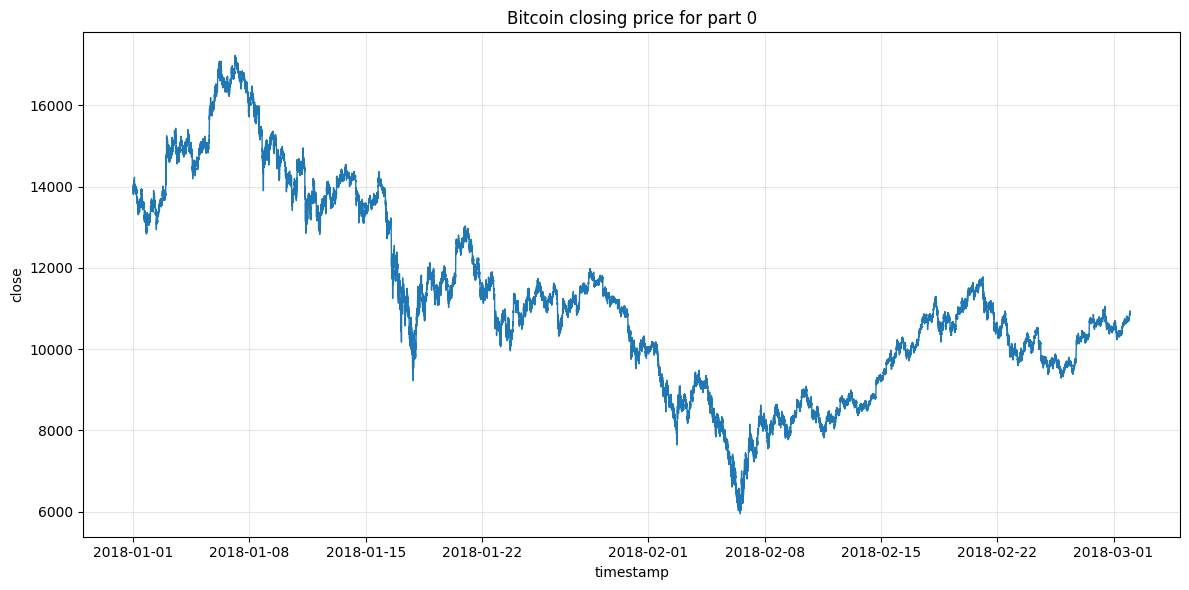

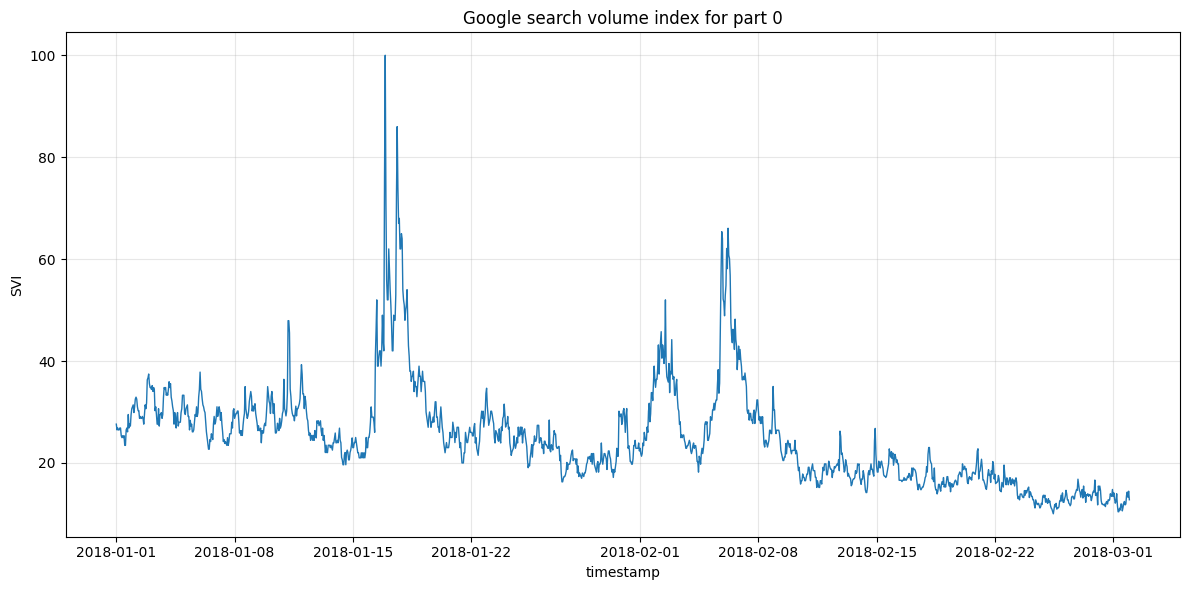

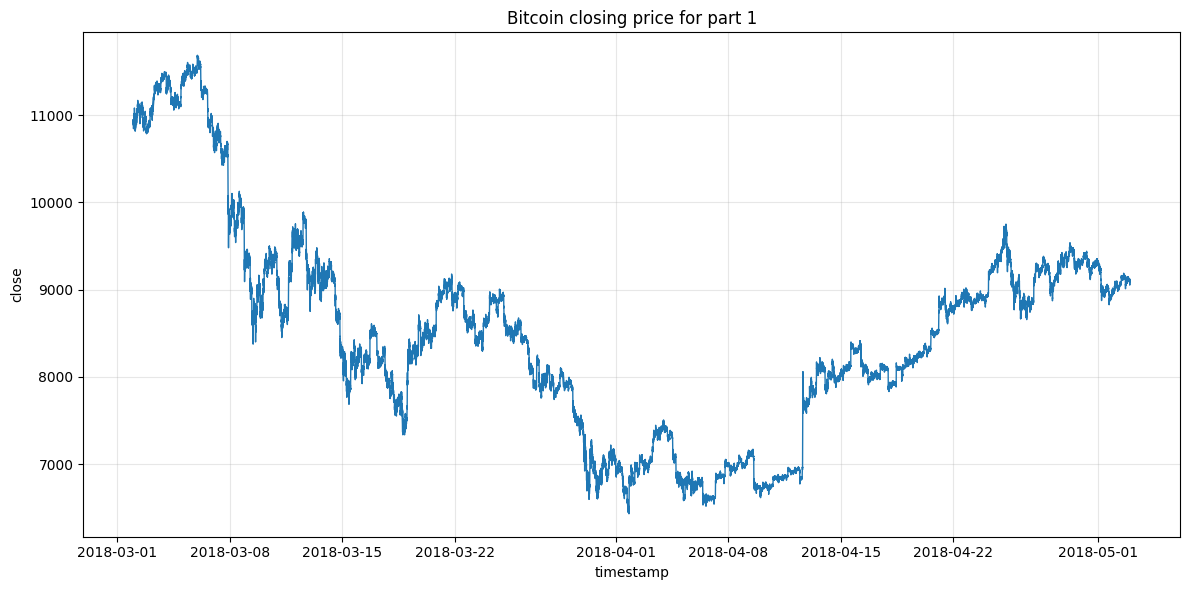

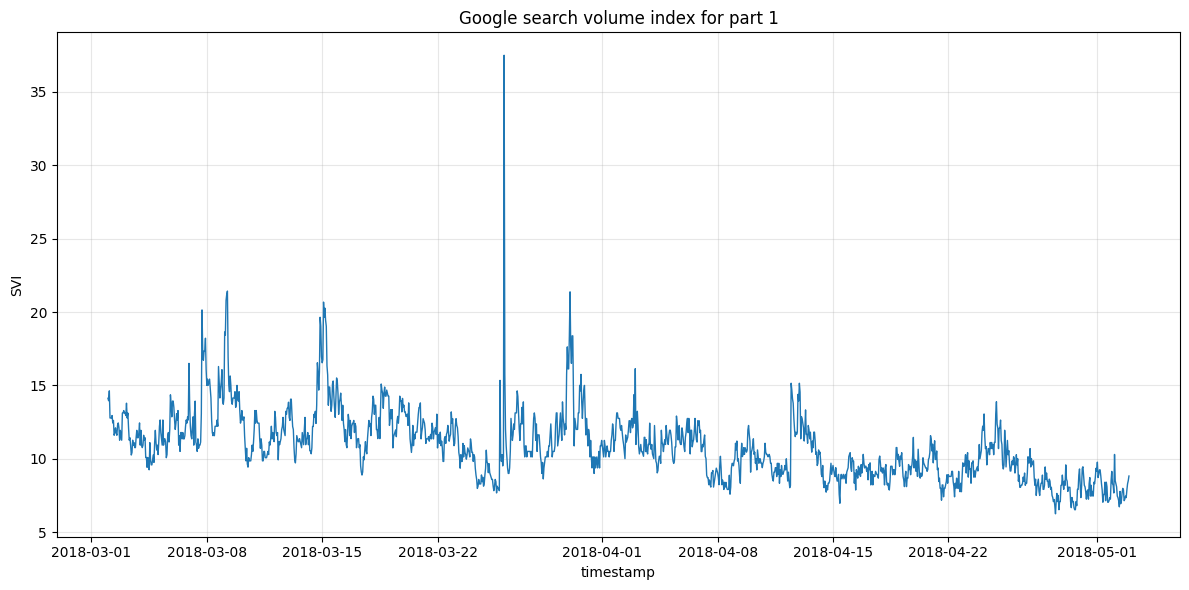

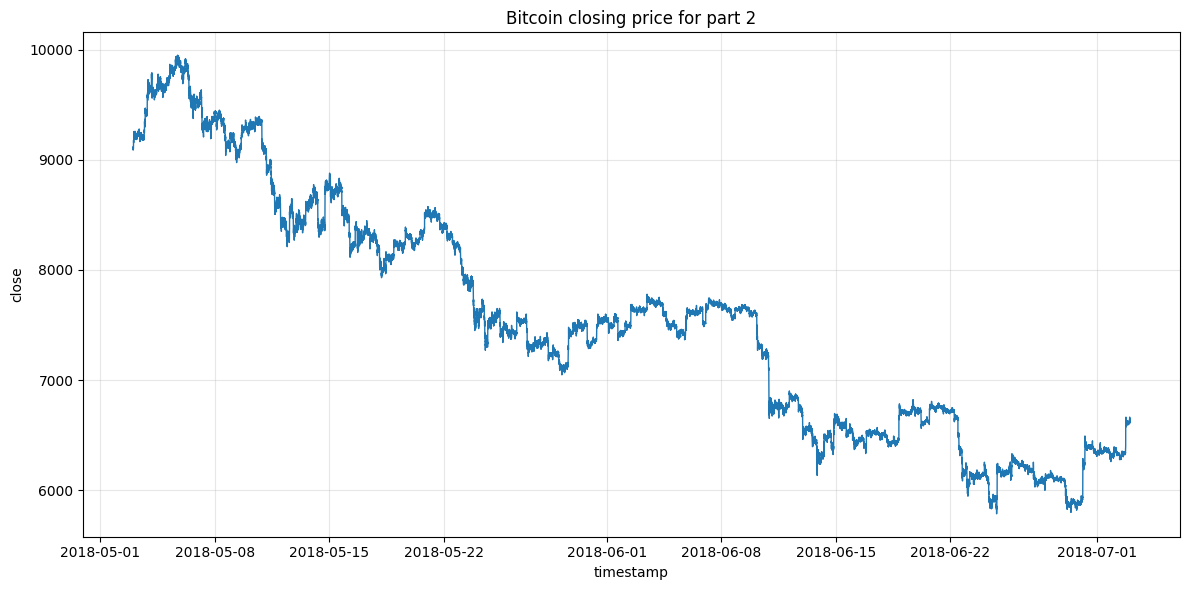

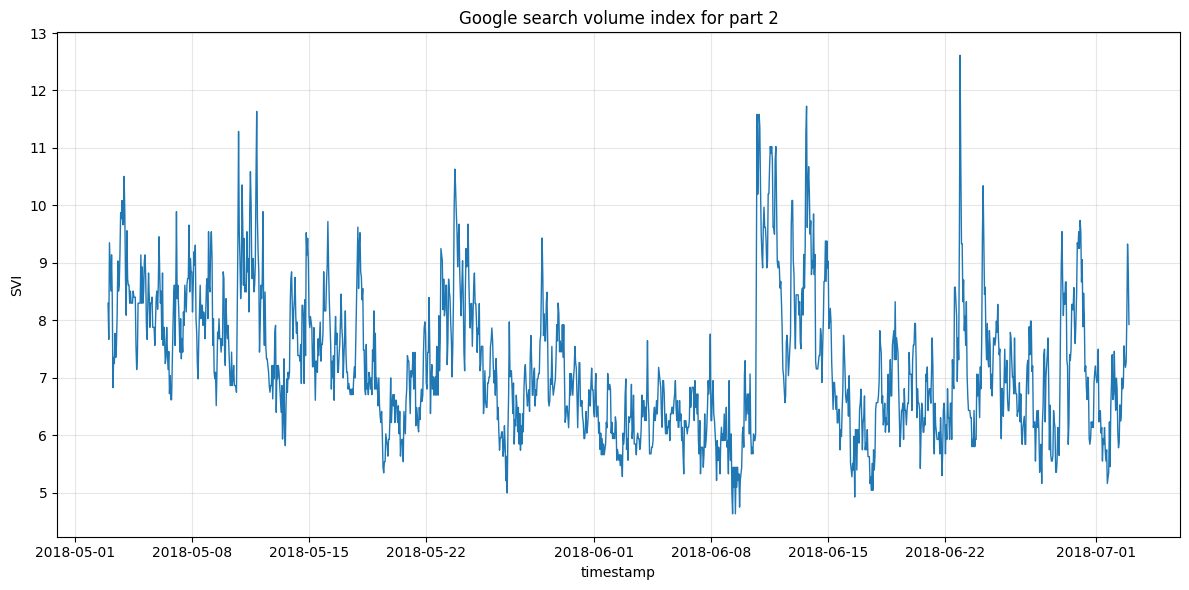

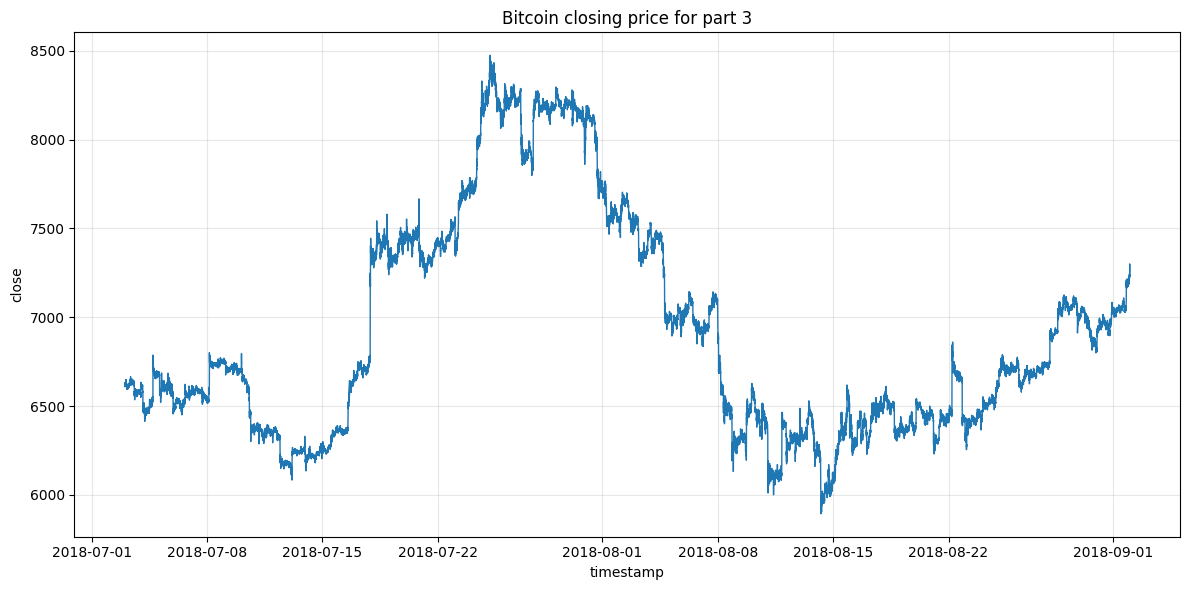

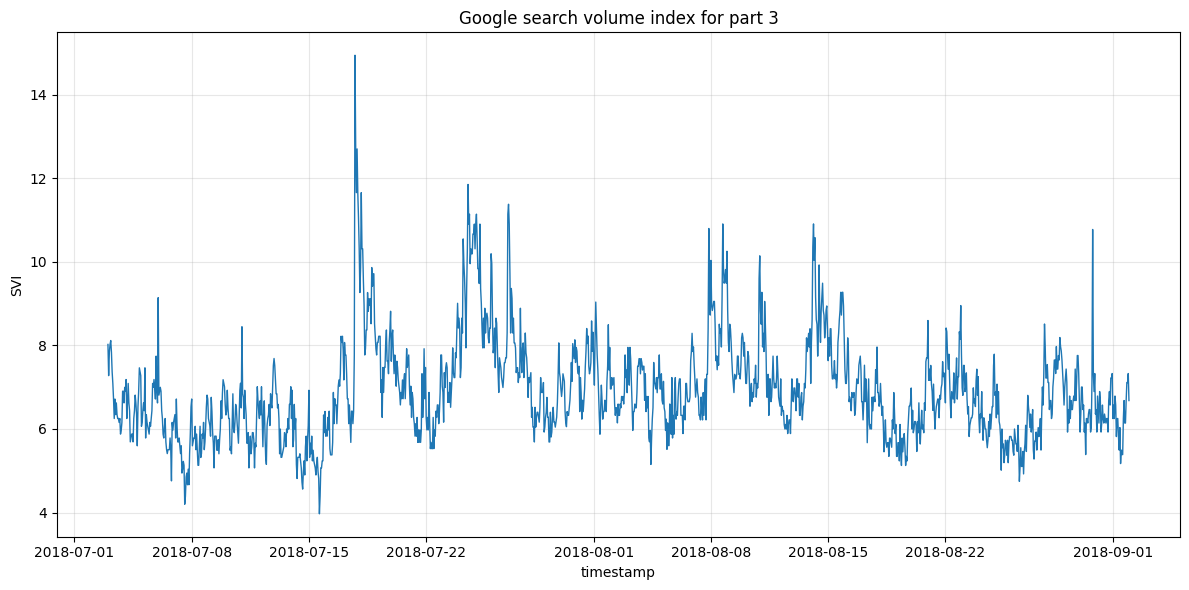

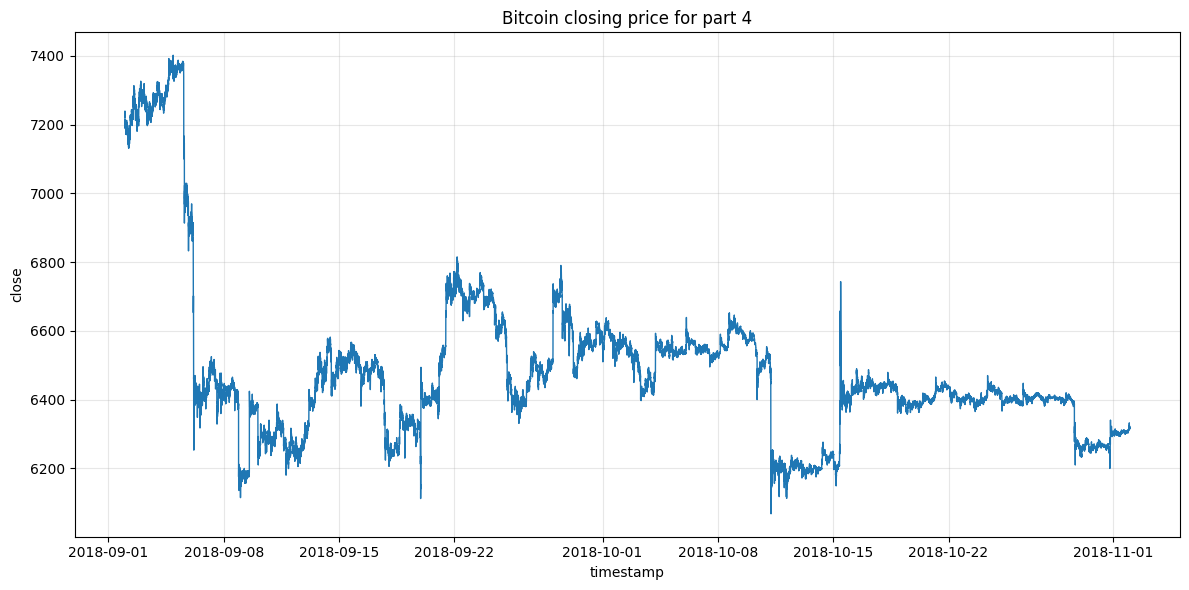

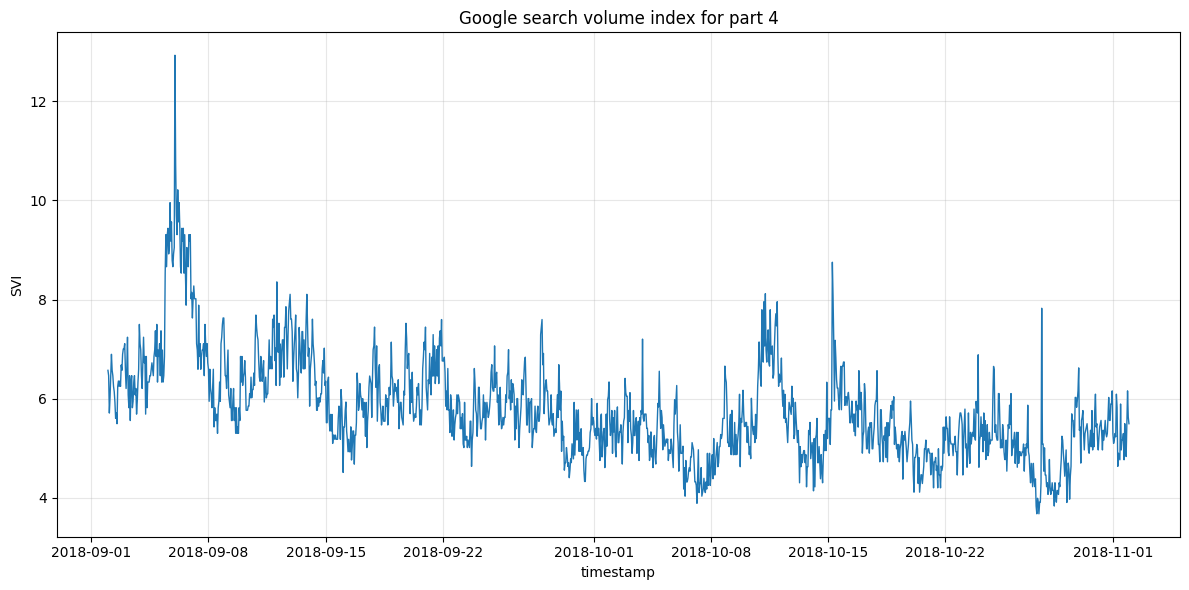

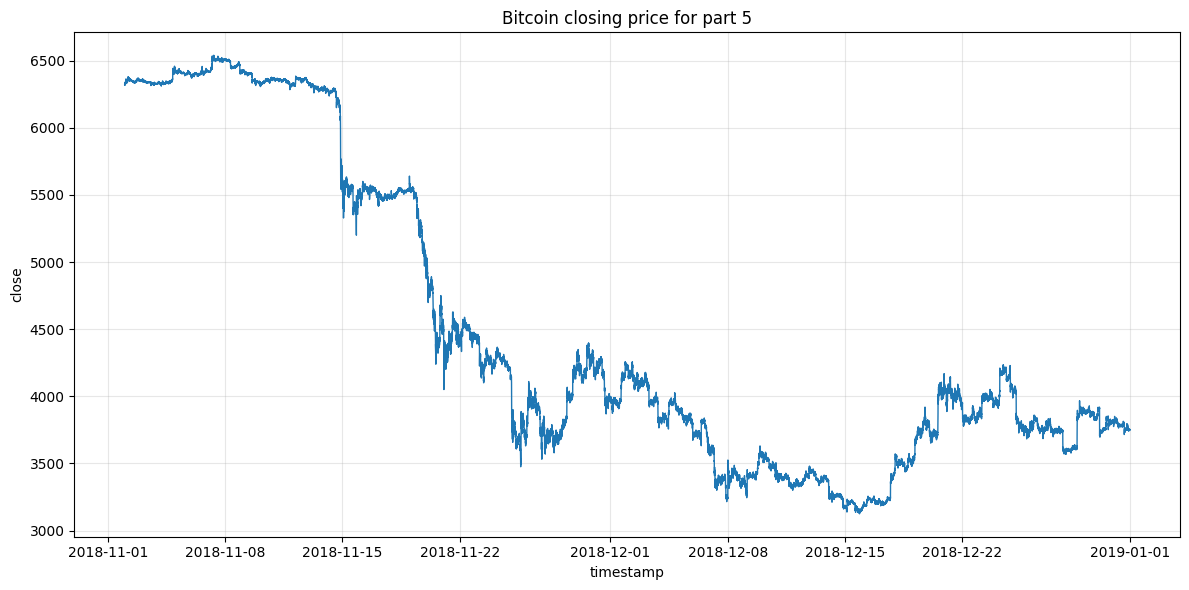

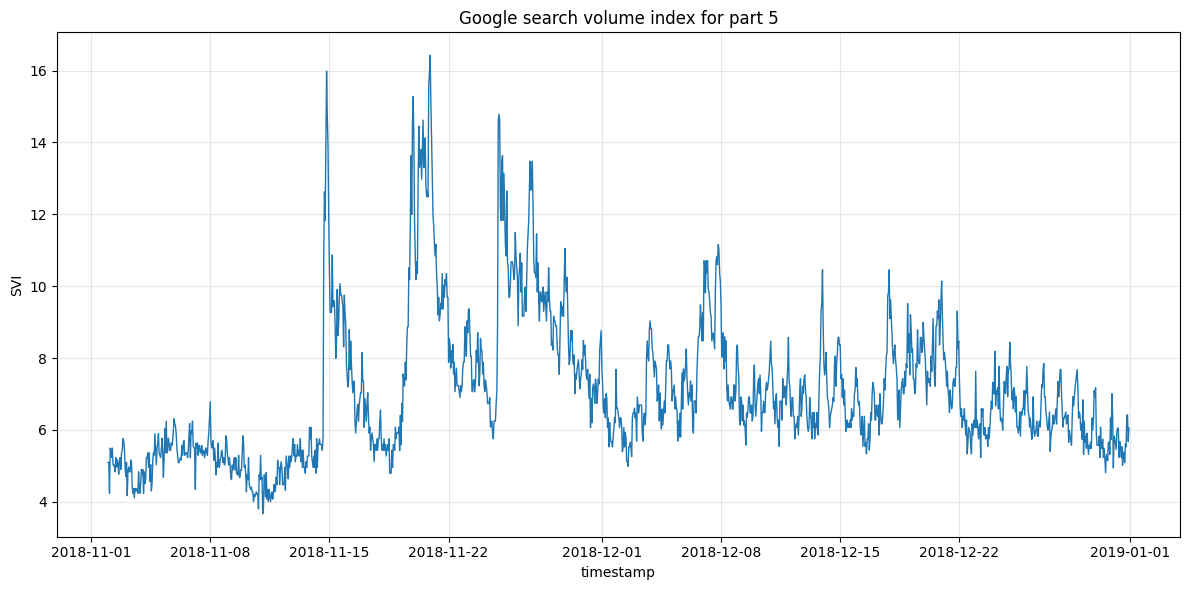

In [6]:
for i, (start, end) in enumerate(ranges):
    dfb = slice_data(df_btc_2018, start, end, ["timestamp", "close"])
    plot_data(dfb, "timestamp", "close", f"Bitcoin closing price for part {i}")
    
    dfs = slice_data(df_search_2018, start, end, ["timestamp", "SVI"])
    plot_data(dfs, "timestamp", "SVI", f"Google search volume index for part {i}")


### Preparing part 0, 1, 2 and 3

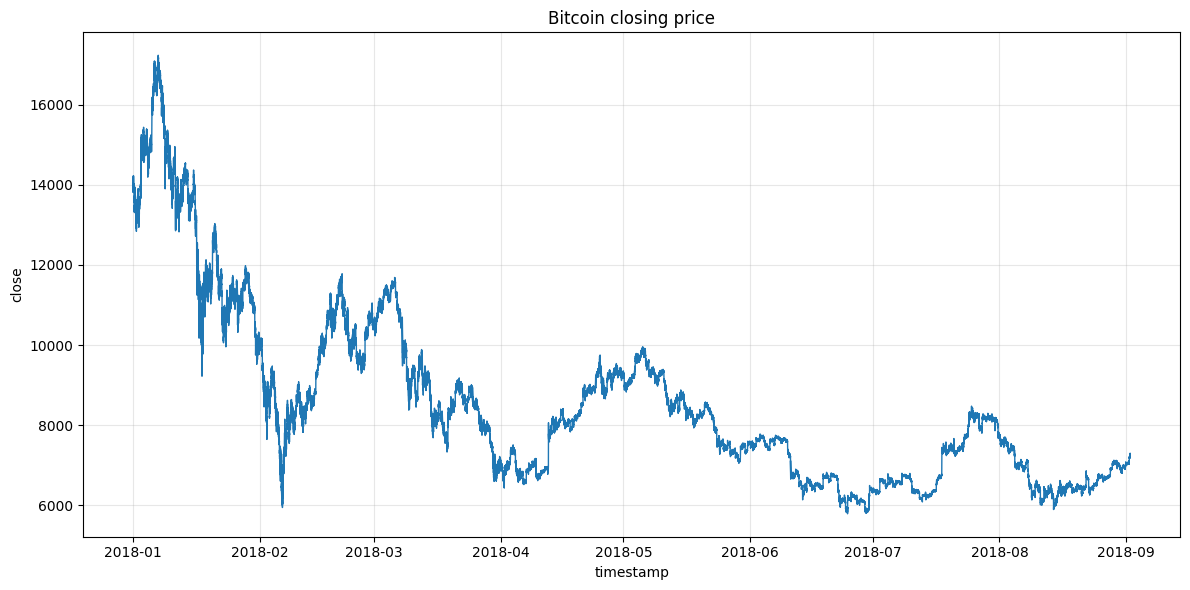

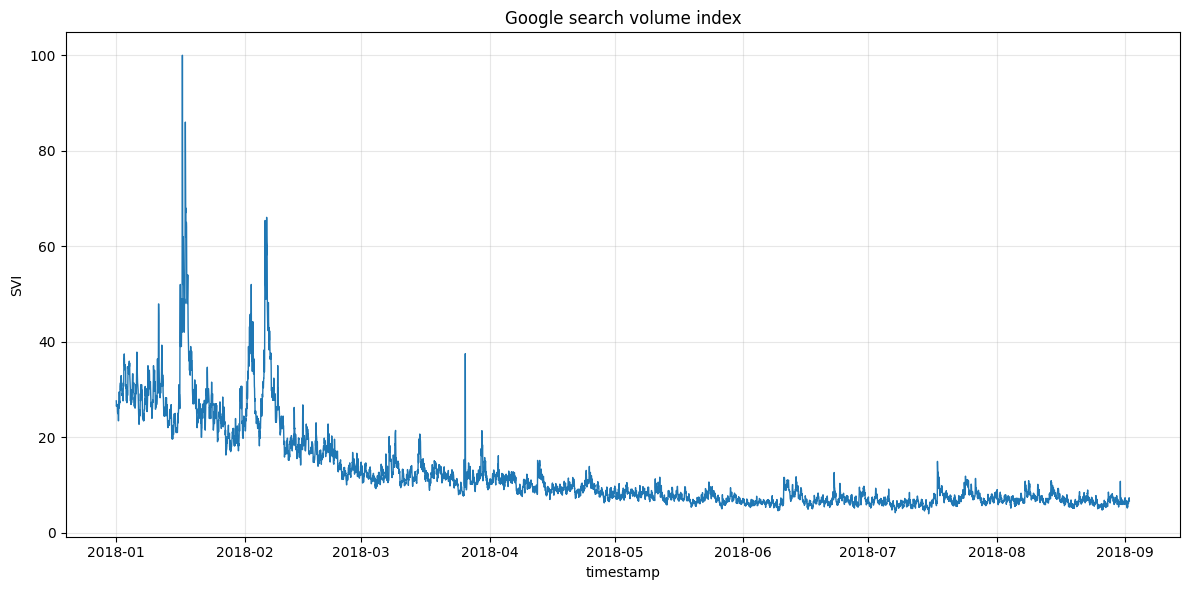

In [7]:
df_btc = slice_data(df_btc_2018, range03[0], range03[1], ["timestamp", "close"])
df_search = slice_data(df_search_2018, range03[0], range03[1], ["timestamp", "SVI"])

plot_data(df_btc, "timestamp", "close", f"Bitcoin closing price")
plot_data(df_search, "timestamp", "SVI", f"Google search volume index")


This section involves the preparation of Google search volume data. The data is checked for stationarity, and changes in the Search Volume Index (SVI) are computed.

In [8]:
# Adfuller test, returns only the p-value. If the p-value is below 0.05 the data is stationary
def ADF(df: pl.DataFrame, x: str):
    result = adfuller(df[x].drop_nulls())
    
    stat = "not stationary"
    if result[1] < 0.05:
        stat = "stationary"

    print(f"The data for {x} is {stat} (p-value = {result[1]:.3e})")


In [9]:
ADF(df_search, "SVI")


The data for SVI is stationary (p-value = 8.345e-05)


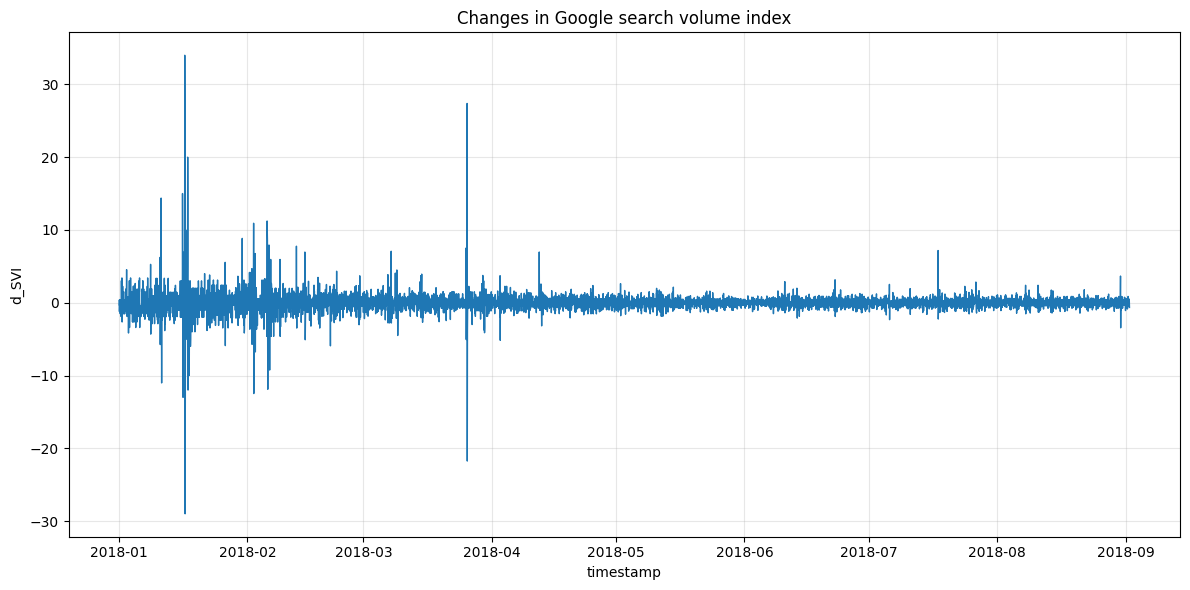

In [10]:
# adding column with differences
df_search = df_search.with_columns([
        (pl.col("SVI") - pl.col("SVI").shift(1)).alias("d_SVI")
    ])

plot_data(df_search, "timestamp", "d_SVI", f"Changes in Google search volume index")


In [11]:
ADF(df_search, "d_SVI")


The data for d_SVI is stationary (p-value = 9.181e-22)


### Preparing data for part 4

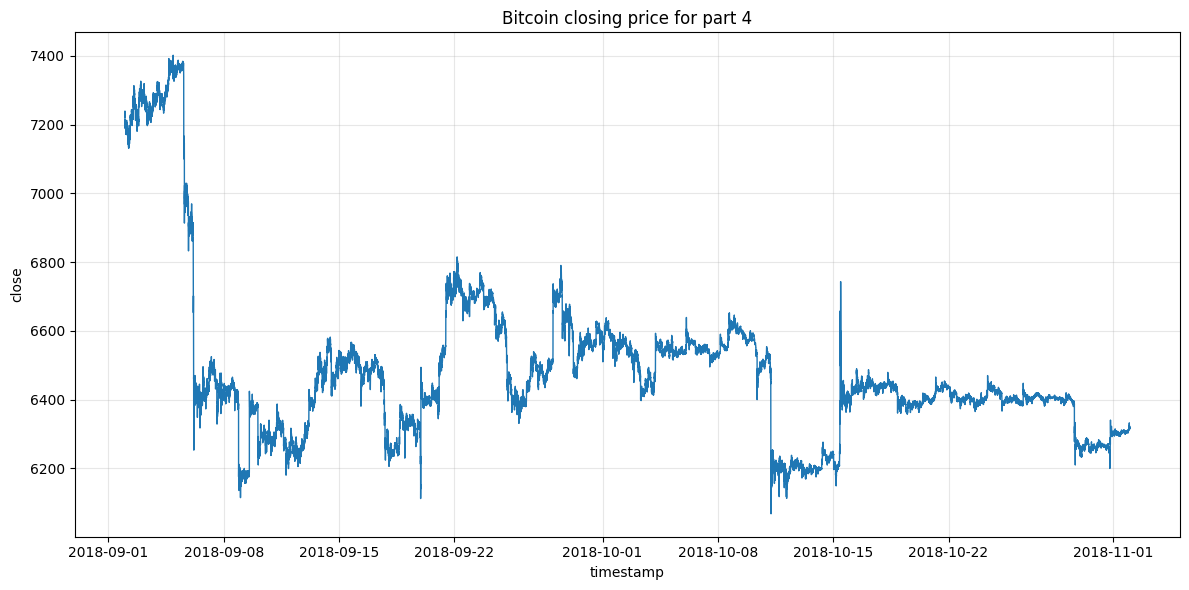

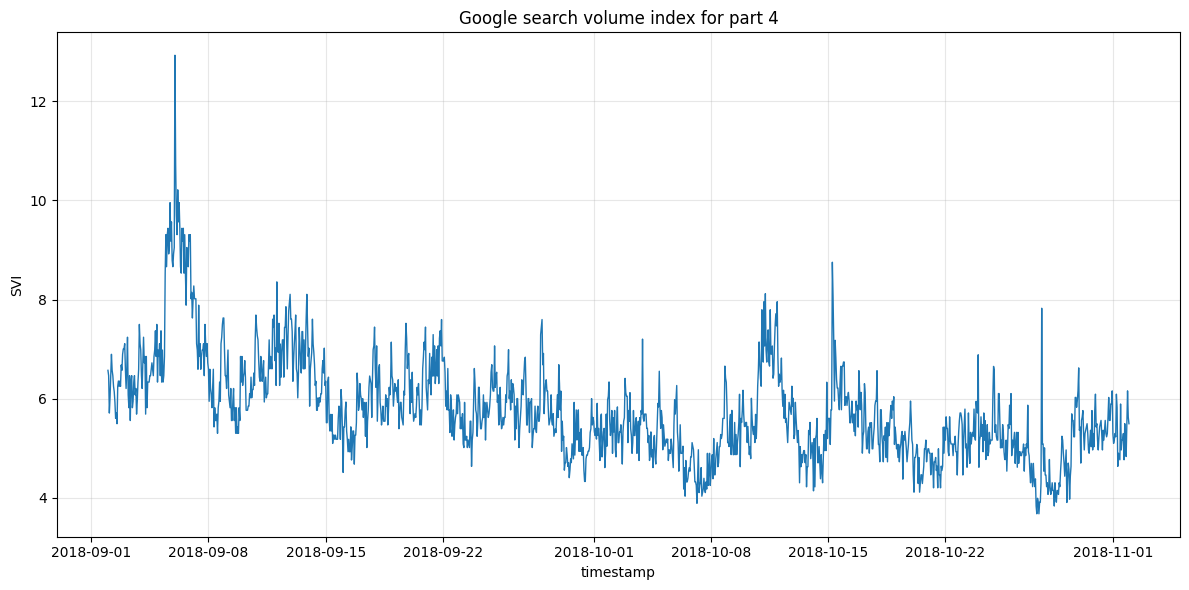

In [12]:
df_btc_4 = slice_data(df_btc_2018, range4[0], range4[1], ["timestamp", "close"])
df_search_4 = slice_data(df_search_2018, range4[0], range4[1], ["timestamp", "SVI"])

plot_data(df_btc_4, "timestamp", "close", f"Bitcoin closing price for part 4")
plot_data(df_search_4, "timestamp", "SVI", f"Google search volume index for part 4")

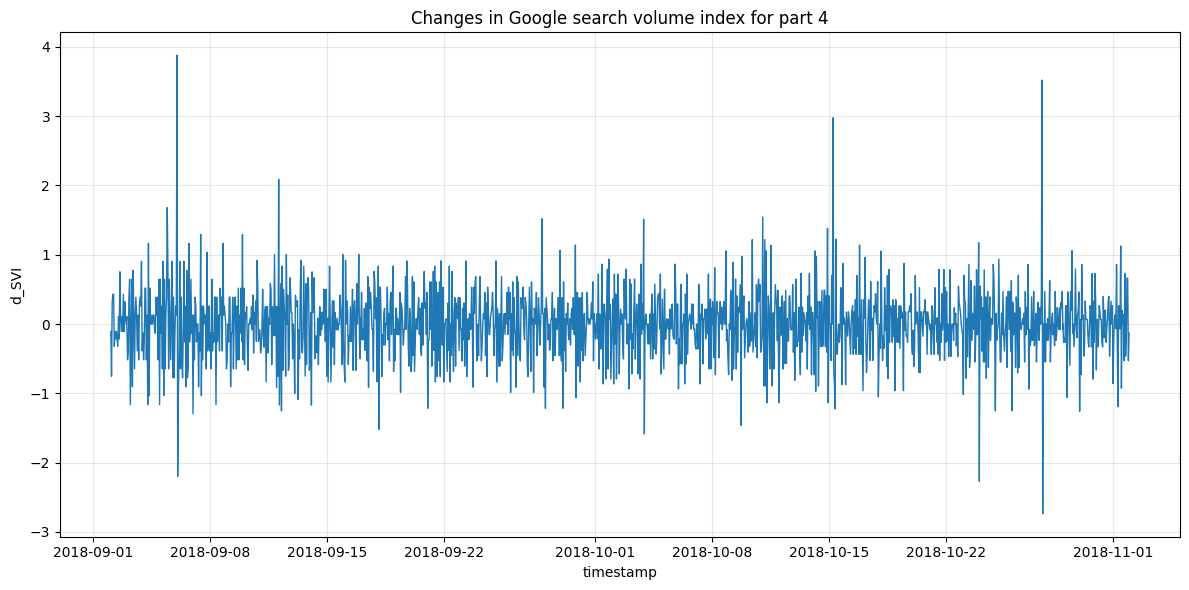

In [13]:
# adding column with differences
df_search_4 = df_search_4.with_columns([
        (pl.col("SVI") - pl.col("SVI").shift(1)).alias("d_SVI")
    ])

plot_data(df_search_4, "timestamp", "d_SVI", f"Changes in Google search volume index for part 4")

## Volatility
Short-term volatility is defined as the standard deviation of Bitcoin prices within a 24-hour window. In this section, the relationship between volatility and Google search volume is examined. It is important to note that the search volume is normalized to a scale between 0 and 100, implying that any future predictions generated by the model should be based on search volume data normalized using the same scale.


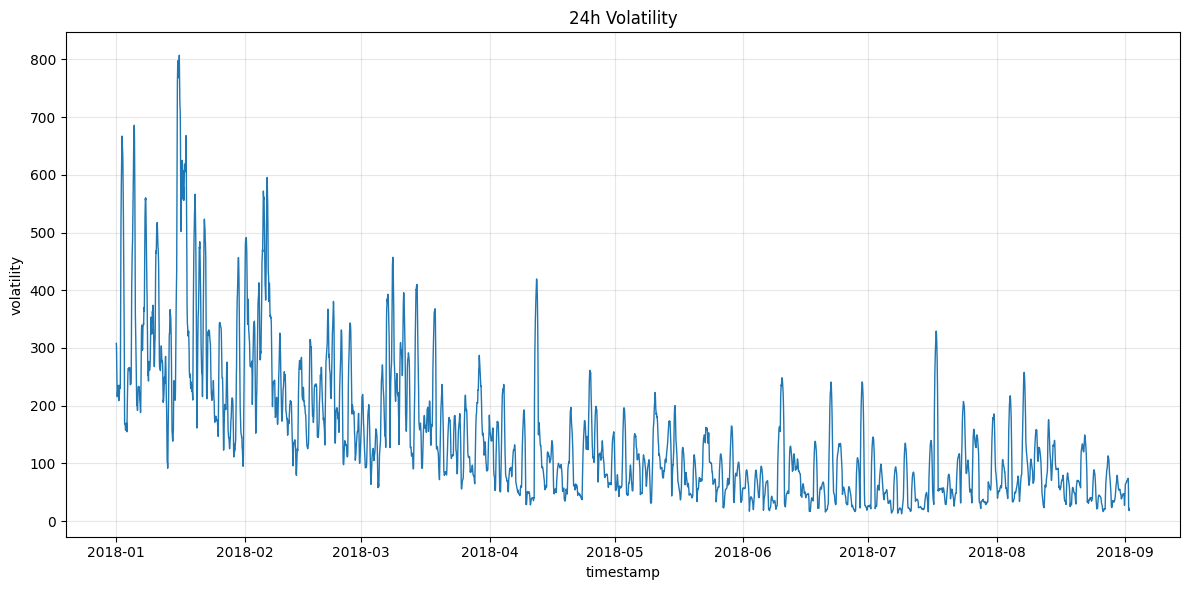

In [14]:
# making a new dataframe with volatility
df_vol = (df_btc.group_by_dynamic(
        index_column="timestamp",
        every="1h",
        period="24h"
    )
    .agg(pl.col("close").std().alias("volatility"))
    )

plot_data(df_vol, "timestamp", "volatility", f"24h Volatility")


In [15]:
ADF(df_vol, "volatility")


The data for volatility is stationary (p-value = 2.280e-05)


In [16]:
def norm_test(df: pl.DataFrame, x: str):
    data = np.array(df[x].drop_nulls())
    data_std = (data - np.mean(data)) / np.std(data)

    stat, p_value = kstest(data_std, 'norm')
    
    norm = "does not have normal distribution"
    if p_value < 0.05:
        norm = "has normal distribution"

    print(f"The data for {x} {norm} (p-value = {p_value:.3e})")


In [17]:
norm_test(df_vol, "volatility")
norm_test(df_search, "SVI")


The data for volatility has normal distribution (p-value = 6.262e-101)
The data for SVI has normal distribution (p-value = 1.410e-240)


Continue with Pearson's correlation test.

In [18]:
# combine SVI and  volatility into one dataframe
df_svi_vol = df_vol.join(
        df_search,
        on="timestamp",
        how="inner"
    )

In [19]:
def corr_test(df: pl.DataFrame, x: str, y: str):
    correlation= df.select(
            pl.corr(x, y)
        ).item()
    print(f"Correlation of {x} and {y}: {correlation:.3f}")


In [20]:
corr_test(df_svi_vol, "SVI", "volatility")


Correlation of SVI and volatility: 0.747


Given the strong linear association observed, we fit a linear regression model to examine whether this relationship can be leveraged for prediction.

In [21]:
# scatter plot with two variables
def plot_scatter(df: pl.DataFrame, x: str, y: str, title: str):
    plt.figure(figsize=(12, 6))
    plt.scatter(df[x], df[y], s=5)
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


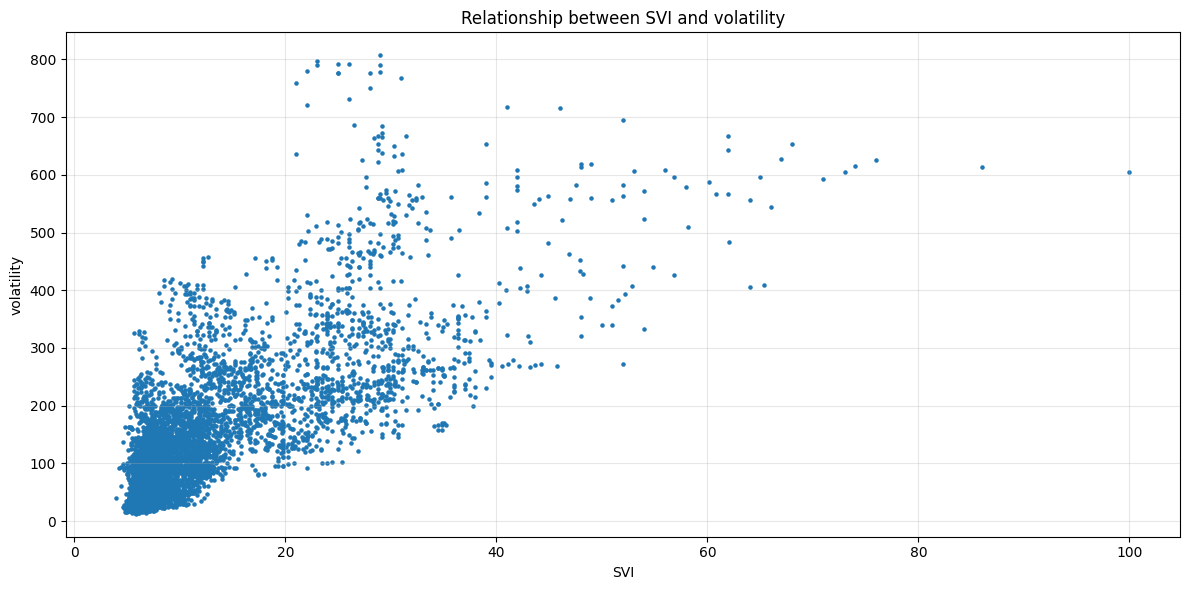

In [22]:
plot_scatter(df_svi_vol, "SVI", "volatility", "Relationship between SVI and volatility")


In [23]:
def lrm(df: pl.DataFrame, x: str, y: str, show_model=True):
    X = np.array(sm.add_constant(df[x]))
    Y = np.array(df[y])
    
    model = sm.OLS(Y, X).fit()
    if show_model:
        print(model.summary())
        
    return model.params[0], model.params[1]


In [24]:
c_vol, b_vol = lrm(df_svi_vol, "SVI", "volatility")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     7416.
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:43:17   Log-Likelihood:                -34191.
No. Observations:                5890   AIC:                         6.839e+04
Df Residuals:                    5888   BIC:                         6.840e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.5188      1.800     10.845      0.0

In [25]:
# scatter plot with two variables and a line
def plot_scatter_lrm(df: pl.DataFrame, x: str, y: str, title: str, c, b):
    plt.figure(figsize=(12, 6))
    plt.scatter(df[x], df[y], s=5)
    
    x_lrm = df[x]
    y_lrm = 0.9154 + 10.4165 * x_lrm
    plt.plot(x_lrm, y_lrm, color='red', lw=1, ls="--", label="LRM")
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()


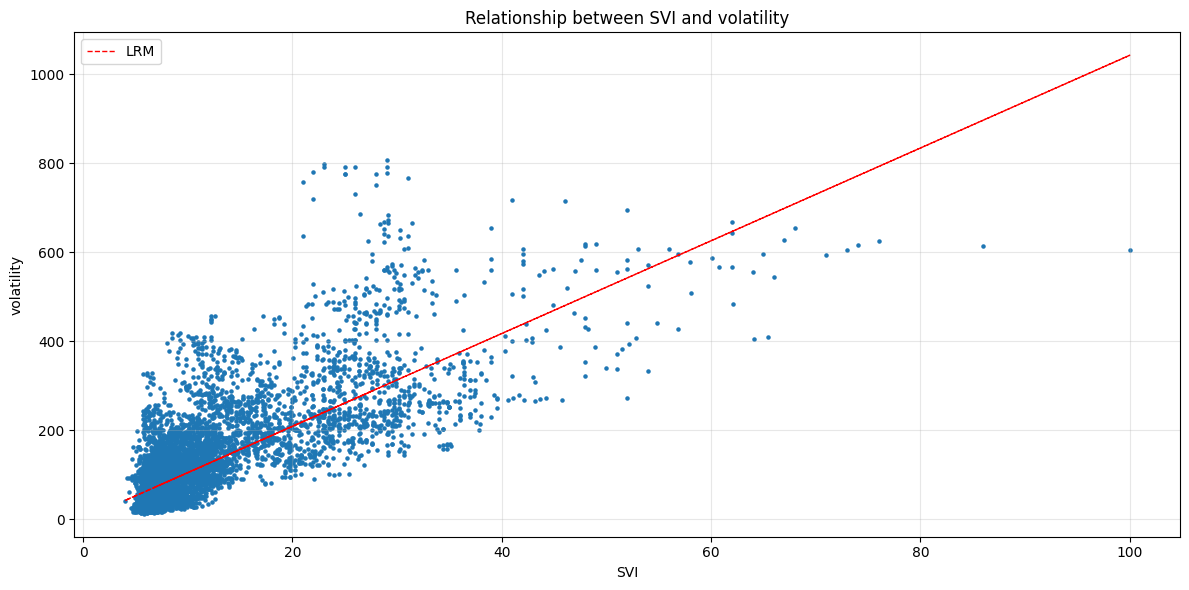

In [26]:
plot_scatter_lrm(df_svi_vol, "SVI", "volatility", "Relationship between SVI and volatility",
                 c_vol, b_vol)


The OLS model explains approximately 56% of the variation in the dependent variable (R² ≈ 0.56), with the predictor x1 showing a significant positive effect (coefficient ≈ 10.15, p < 0.05). The intercept is 19.52 and is also statistically significant (p < 0.05). However, the residuals exhibit strong positive autocorrelation (Durbin-Watson ≈ 0.058). Still we look to test the predictive properties of the model.

### Validating the LRM for SVI x volatility


In [27]:
# actual volatility for part 4
df_vol_4 = (df_btc_4.group_by_dynamic(
        index_column="timestamp",
        every="1h",
        period="24h"
    )
    .agg(pl.col("close").std().alias("volatility"))
    )


In [28]:
# predicted volatility for part 4
df_pred_vol_4 = (df_search_4.with_columns(
    pred_vol = c_vol + b_vol * pl.col("SVI"))
    .select(["timestamp", "pred_vol"]))


In [29]:
# plot data (two functions)
def plot_data_2(df1: pl.DataFrame, x1: str, y1: str, l1: str, 
                df2: pl.DataFrame, x2: str, y2: str, l2:str, title: str):
    
    plt.figure(figsize=(12, 6))
    plt.plot(df1[x1], df1[y1], lw=1, label=l1)
    plt.plot(df2[x2], df2[y2], lw=1, label=l2)
    
    plt.title(title)
    plt.xlabel(f"{x1}")
    plt.ylabel(f"{y1}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()


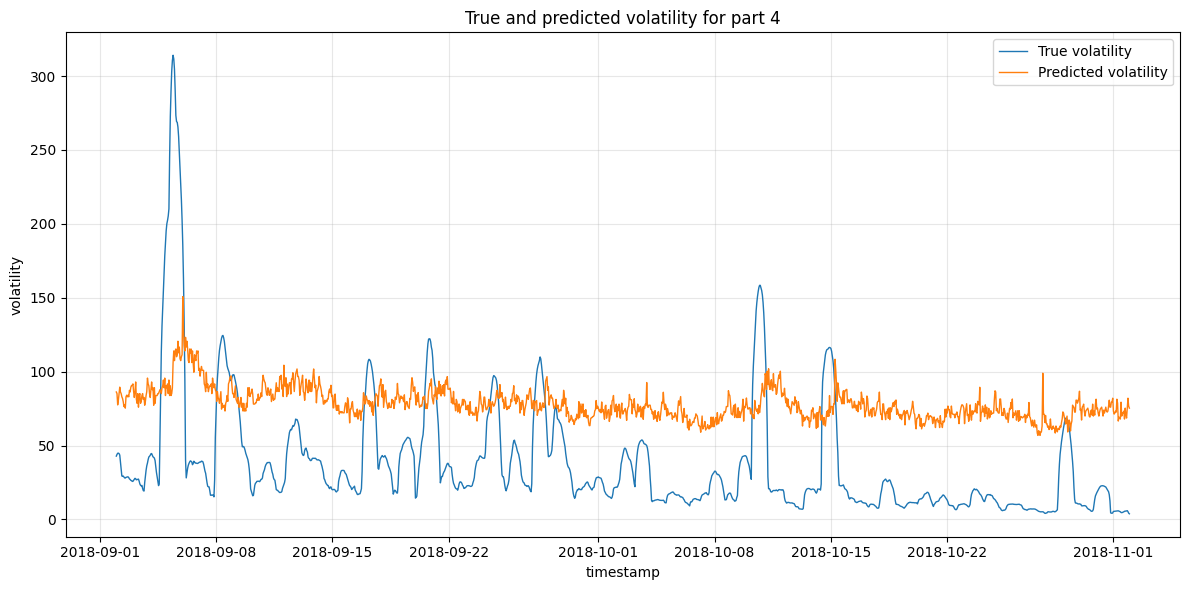

In [30]:
plot_data_2(df_vol_4, "timestamp", "volatility", "True volatility",
            df_pred_vol_4, "timestamp", "pred_vol", "Predicted volatility",
            "True and predicted volatility for part 4")


#### Hypothesis testing
Although from the graph it's already visable that the prediction isn't very accurate. We want to test if there is any predictive power at all. To test that we compare the error of the model and the benchmark. 

$L = (y_t - \hat{y}_t)^2$, $y_t$ is the true value, $\hat{y}_t$ is the predicted value.

For the benchmark random walk is used. Each step in our random walk is $\pm$ the average step for volatility in part 0 through 3.

- $H_0$: There is no predictive power $mean(L^{model}_t - L^{bench}_t) \geq 0$
- $H_1$: There is predictive power $mean(L^{model}_t - L^{bench}_t) < 0$

In [31]:
df_vol_4_loss = df_vol_4.join(
    df_pred_vol_4,
    on="timestamp",
    how="inner")

In [32]:
def loss_function(df: pl.DataFrame, x: str, y: str, z: str):
    return (df
        .with_columns(((pl.col(x) - pl.col(y)) ** 2).alias(z))
    )


In [33]:
df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "pred_vol", "loss_model")


In [34]:
def random_walk(df: pl.DataFrame, x: str, start: float, step: float):
    n = df.height

    # Generate random steps (+step or -step)
    steps = np.random.choice([-step, step], size=n)

    # Build the random walk
    walk = np.empty(n)
    walk = start + np.cumsum(steps)

    return df.with_columns(
        pl.Series(name=x, values=walk)
    )


In [35]:
# step size
step = df_vol.select(
    (pl.col("volatility") - pl.col("volatility").shift(1)).mean()
).item()

start = df_vol["volatility"][-1]  # last known volatility

df_vol_4_loss = random_walk(df_vol_4_loss, "random_walk", start, step)


In [36]:
df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "random_walk", "loss_bench")


In [37]:
# computind difference (dt) in loss
df_vol_4_loss = df_vol_4_loss.with_columns(
    d = pl.col("loss_model") - pl.col("loss_bench")
)


In [38]:
def plot_hist(data, x: str, title: str, k: int):
    plt.figure(figsize=(12, 6))
    plt.hist(data, k, density=True)
    
    # Confidence intervals
    mean = np.mean(data)
    ci_lower, ci_upper = np.percentile(data, [2.5, 97.5])

    # Plot CI and mean
    plt.axvline(mean, linestyle="--", linewidth=1, color="r", label=f"Mean: {mean:.3f}")
    plt.axvline(ci_lower, linestyle="--", linewidth=1, color="k", label=f"95% CI [{ci_lower:.2f}, {ci_upper:.2f}]")
    plt.axvline(ci_upper, linestyle="--", linewidth=1, color="k")
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"frequency")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()


In [39]:
# recieves an array that is bootstrapped
# returns an array of means
def bootstrap_means(data: np.array, N):
    rng = np.random.default_rng(seed=42)
    
    boot_means = []
    for _ in range(N):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    
    return boot_means


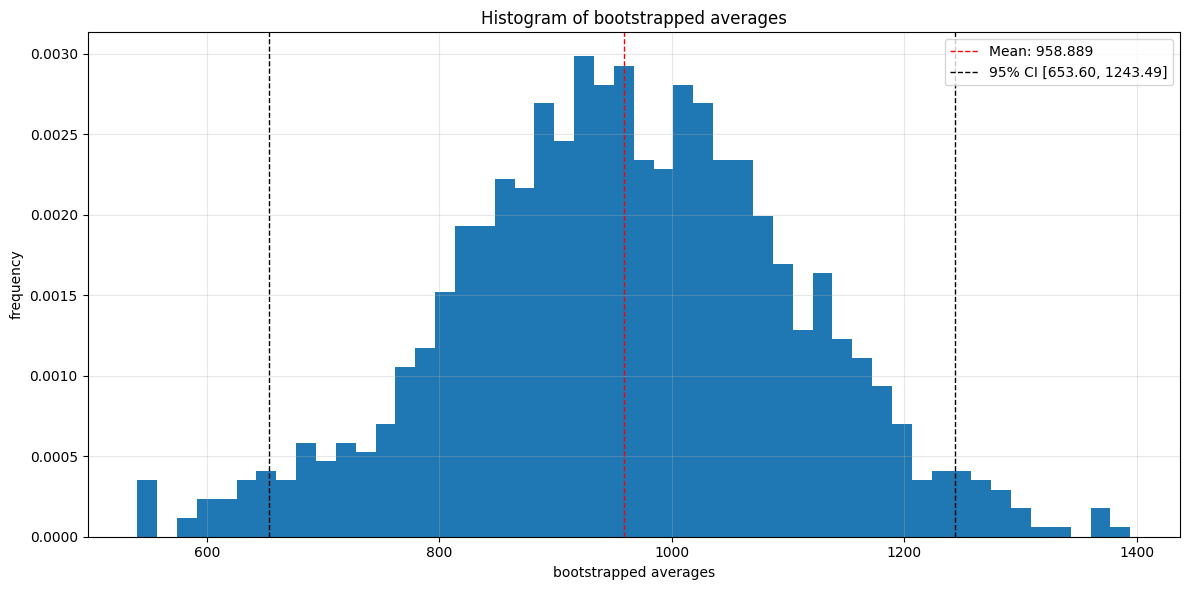

In [40]:
boot_means = bootstrap_means(np.array(df_vol_4_loss["d"]), 10**3)
plot_hist(boot_means, "bootstrapped averages", "Histogram of bootstrapped averages", 50)


The 95% confidence interval for the mean loss differential $L^{model}_t - L^{bench}_t$ lies above 0, indicating that the average is greater than 0. Therefore, we fail to reject the null hypothesis of no predictive power.

### Changes in SVI x Volatility

In [41]:
norm_test(df_search, "d_SVI")


The data for d_SVI has normal distribution (p-value = 6.687e-141)


In [42]:
corr_test(df_svi_vol, "d_SVI", "volatility")

Correlation of d_SVI and volatility: 0.027


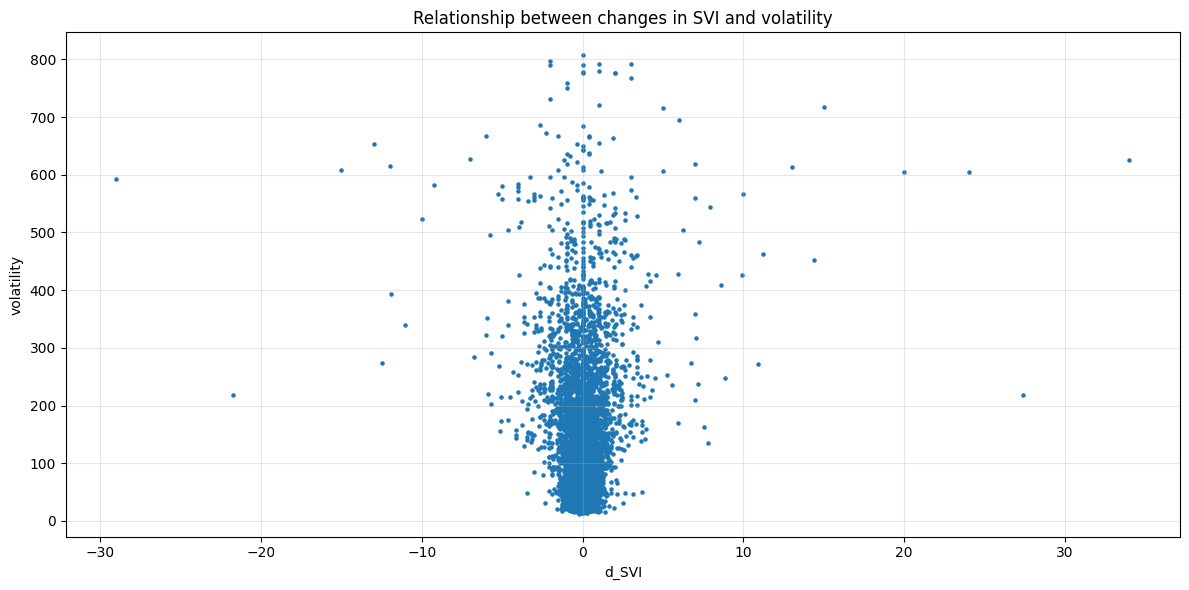

In [43]:
plot_scatter(df_svi_vol, "d_SVI", "volatility", "Relationship between changes in SVI and volatility")

There is essentially no linear relationship between changes in SVI and volatility.

### Changes in SVI x changes in volatility

In [44]:
df_vol = df_vol.with_columns([
        (pl.col("volatility") - pl.col("volatility").shift(1)).alias("d_vol")
    ])

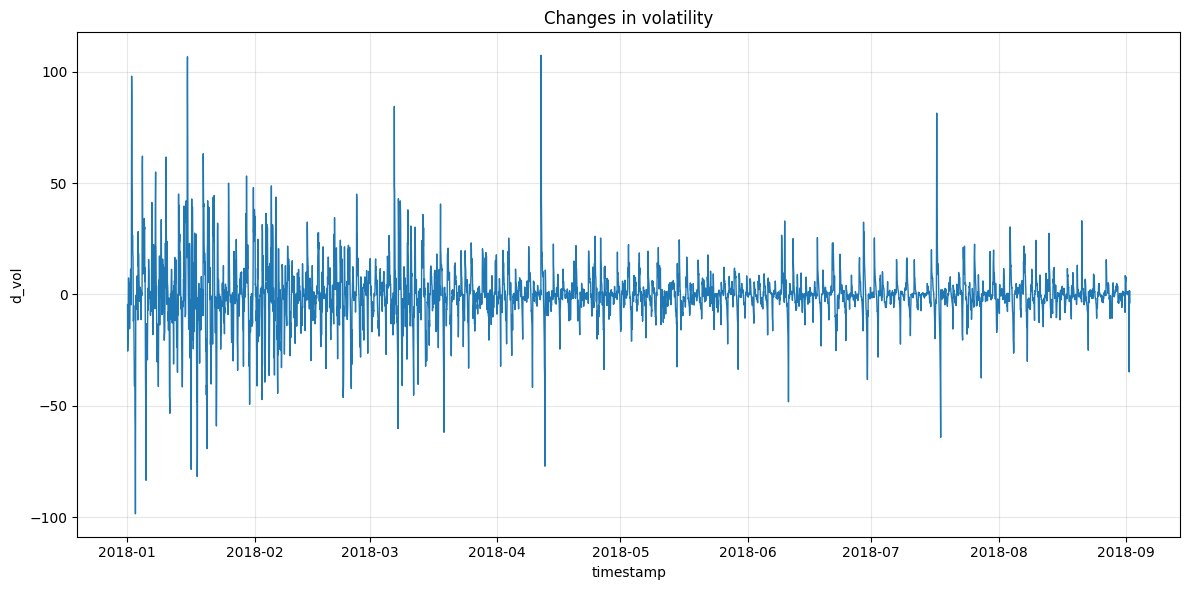

In [45]:
plot_data(df_vol, "timestamp", "d_vol", "Changes in volatility")

In [46]:
ADF(df_vol, "d_vol")
norm_test(df_vol, "d_vol")

The data for d_vol is stationary (p-value = 2.022e-30)
The data for d_vol has normal distribution (p-value = 2.127e-97)


In [47]:
df_dsvi_vol = (df_vol.join(
    df_search,
    on="timestamp",
    how="inner")).select(["timestamp", "d_vol", "d_SVI"])


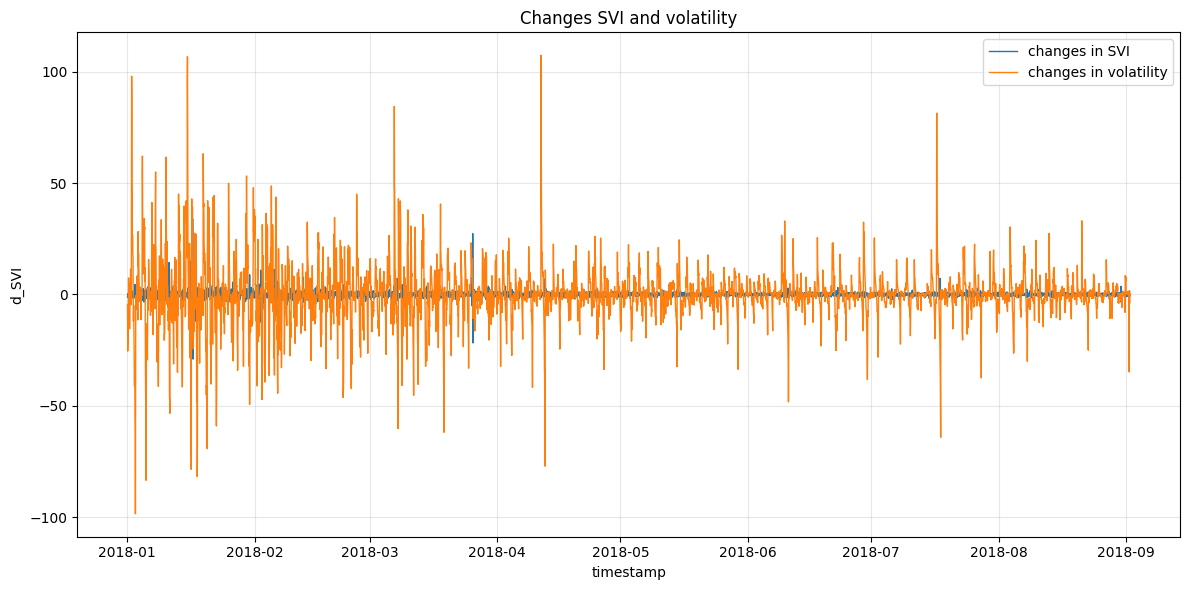

In [48]:
plot_data_2(df_dsvi_vol, "timestamp", "d_SVI", "changes in SVI", 
            df_dsvi_vol, "timestamp", "d_vol", "changes in volatility", "Changes SVI and volatility")

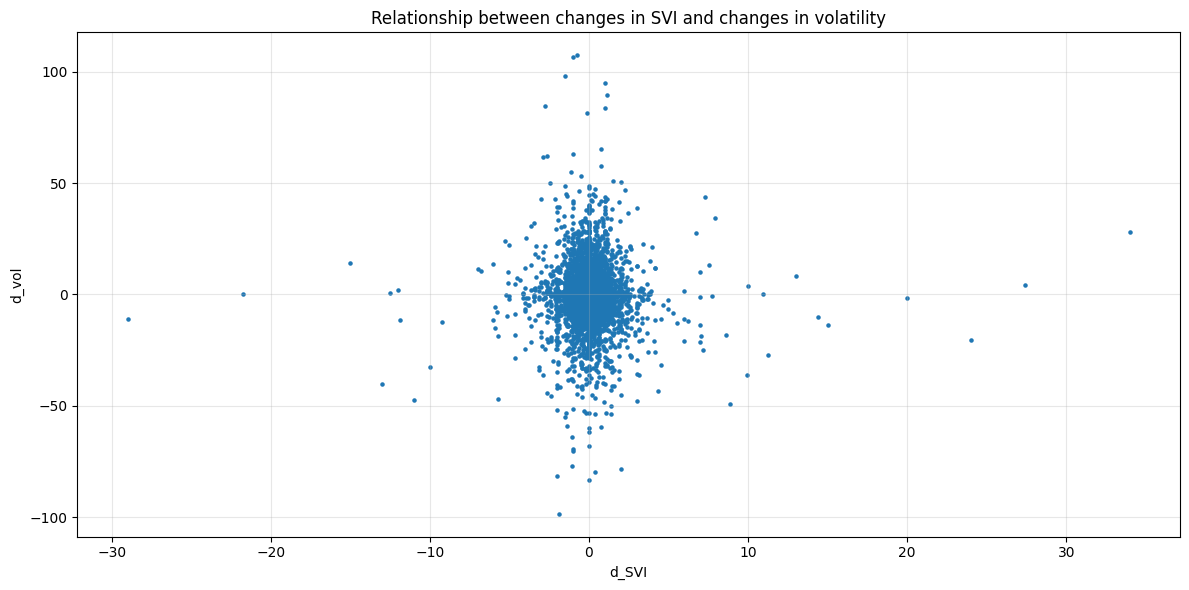

In [49]:
plot_scatter(df_dsvi_vol, "d_SVI", "d_vol", "Relationship between changes in SVI and changes in volatility")

In [50]:
corr_test(df_dsvi_vol, "d_SVI", "d_vol")

Correlation of d_SVI and d_vol: -0.004


There is no linear correlation between the changes in SVI and changes in volatility.

## Momentum

Momentum is defined as: $M = V_t - V_{t - x}$

In the following section the relationship between momentum and search volume index, as well as changes in search volume.

In [51]:
hours = [1, 6, 12, 24, 48]

df_btc_hourly = df_btc.filter(
    (pl.col("timestamp").dt.minute() == 0) &
    (pl.col("timestamp").dt.second() == 0)
)

df_momentum = df_btc_hourly.select(
    [
        "timestamp",
        *[
            (pl.col("close") - pl.col("close").shift(h)).alias(f"price_diff_{h}h")
            for h in hours
        ]
    ]
)


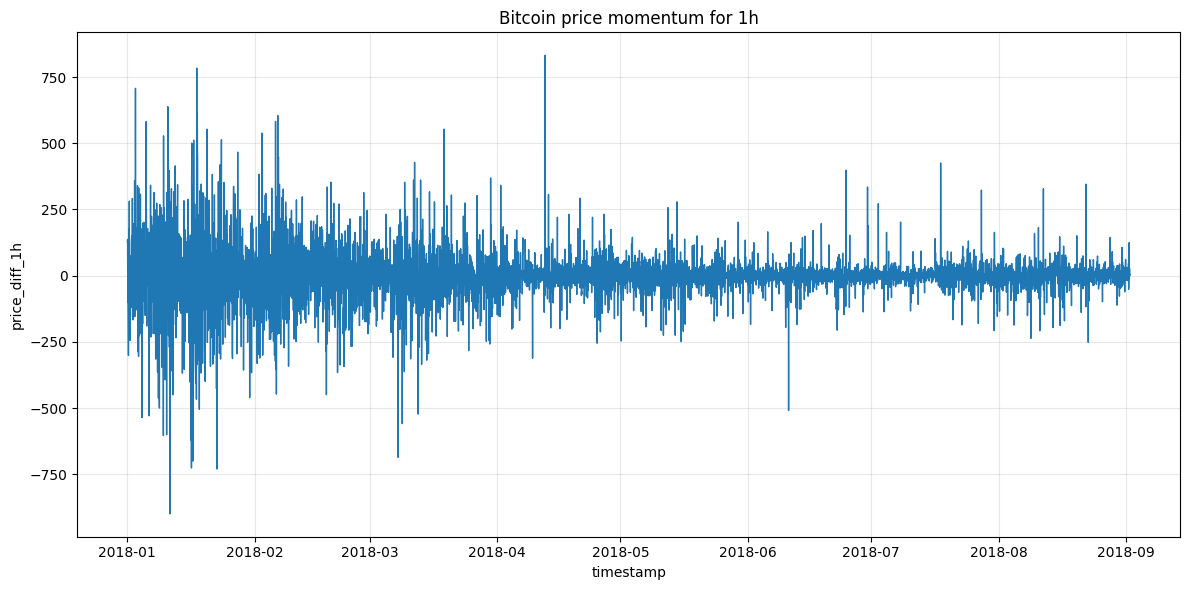

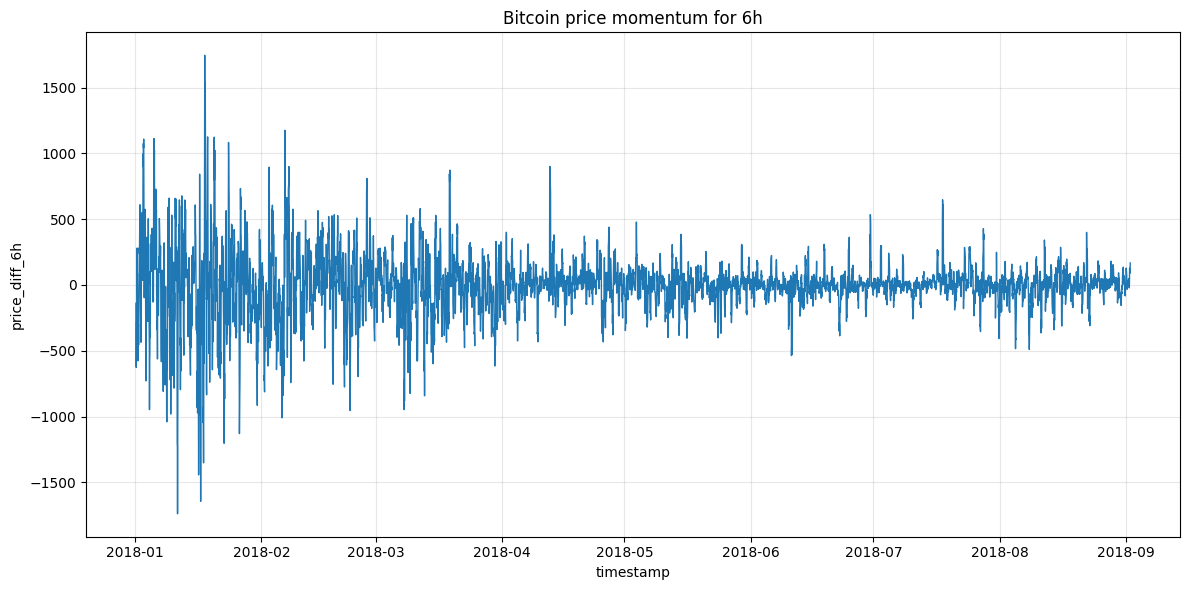

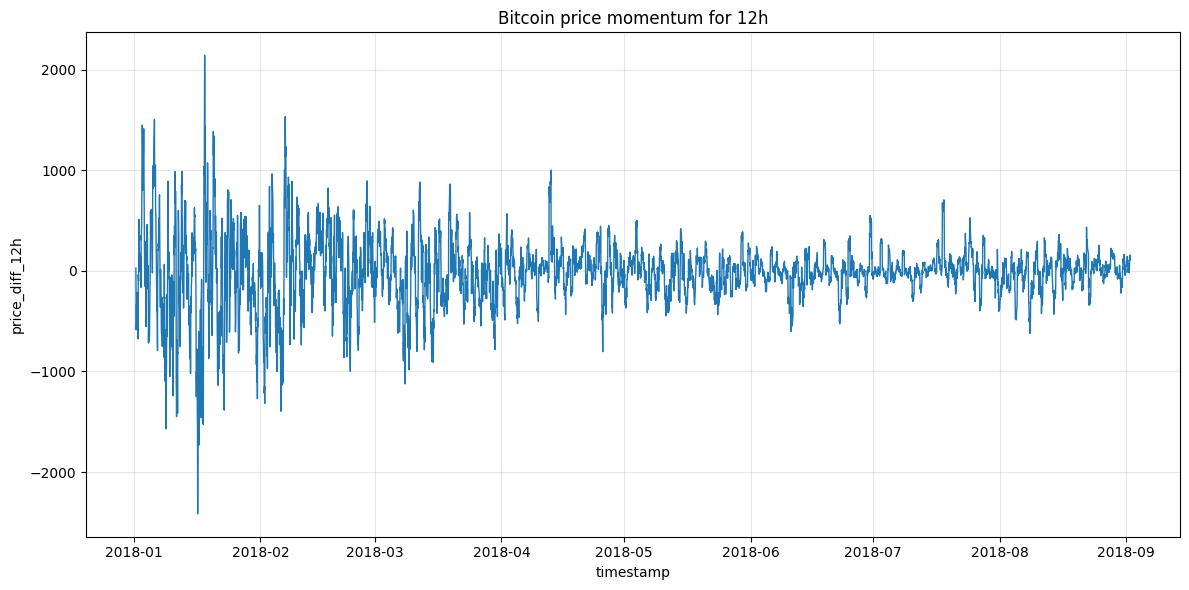

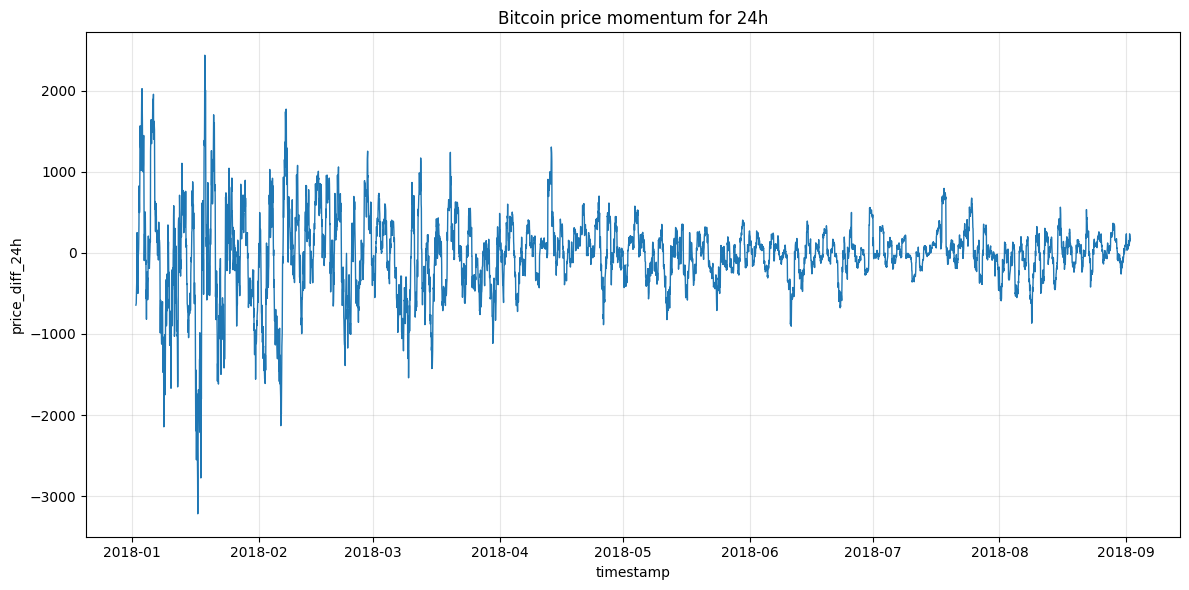

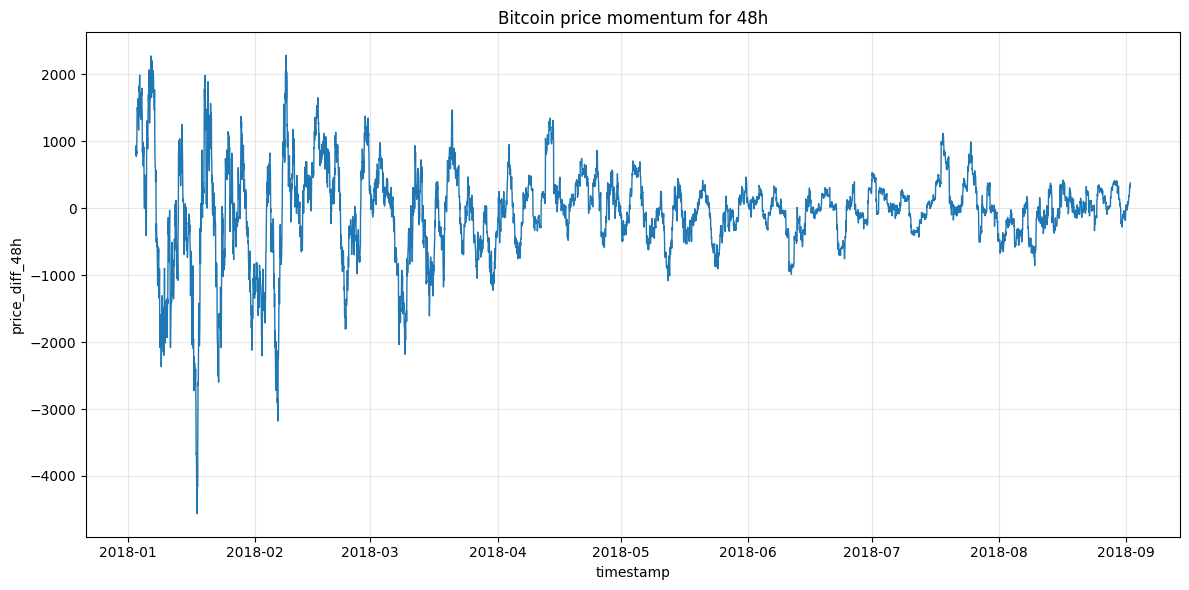

In [52]:
for h in hours:
    plot_data(df_momentum, "timestamp", f"price_diff_{h}h", f"Bitcoin price momentum for {h}h")


In [53]:
for h in hours:
    ADF(df_momentum, f"price_diff_{h}h")


The data for price_diff_1h is stationary (p-value = 1.235e-27)
The data for price_diff_6h is stationary (p-value = 5.937e-24)
The data for price_diff_12h is stationary (p-value = 1.748e-24)
The data for price_diff_24h is stationary (p-value = 2.871e-15)
The data for price_diff_48h is stationary (p-value = 2.591e-15)


In [54]:
# combine SVI and  volatility into one dataframe
df_svi_mom = df_momentum.join(
        df_search,
        on="timestamp",
        how="inner"
    )


In [55]:
for h in hours:
    corr_test(df_svi_mom, "SVI", f"price_diff_{h}h")


Correlation of SVI and price_diff_1h: -0.034
Correlation of SVI and price_diff_6h: -0.081
Correlation of SVI and price_diff_12h: -0.131
Correlation of SVI and price_diff_24h: -0.201
Correlation of SVI and price_diff_48h: -0.271


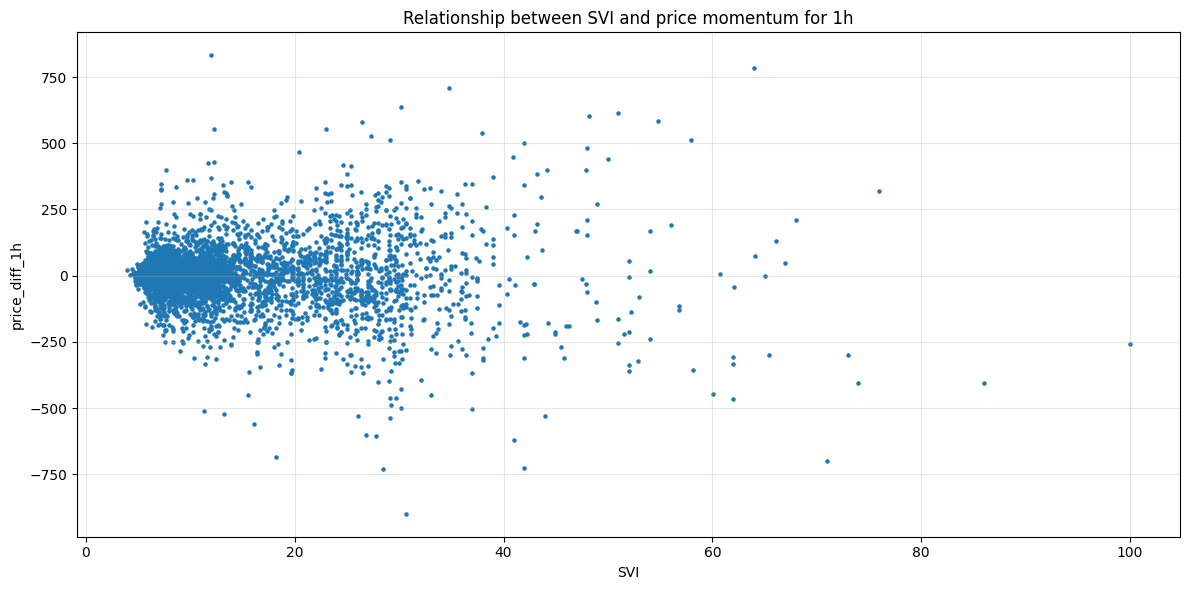

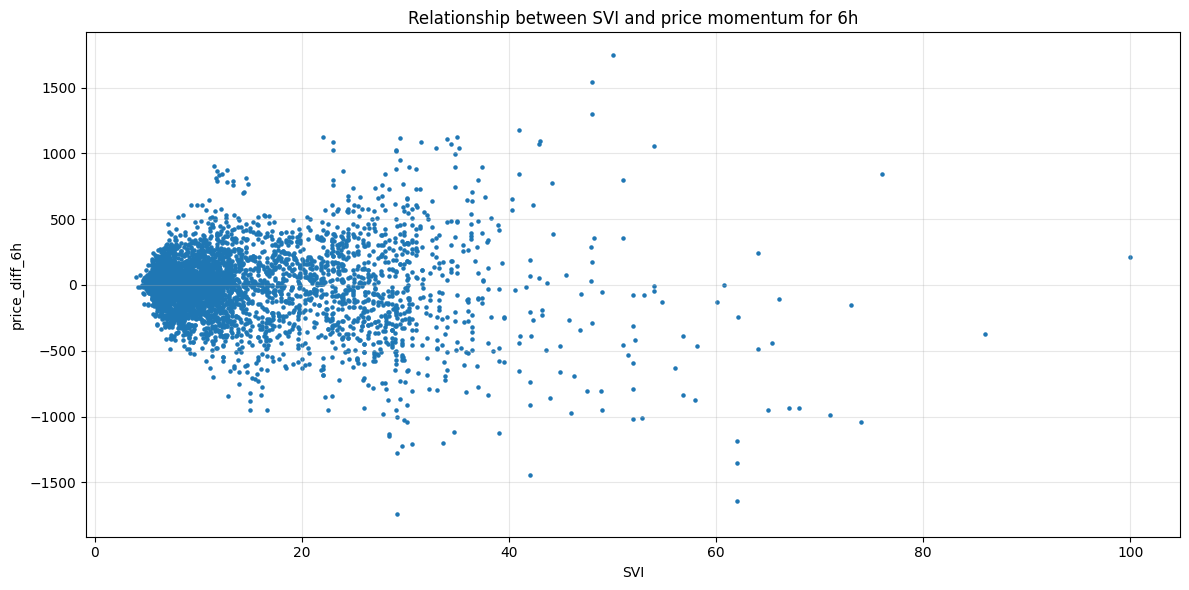

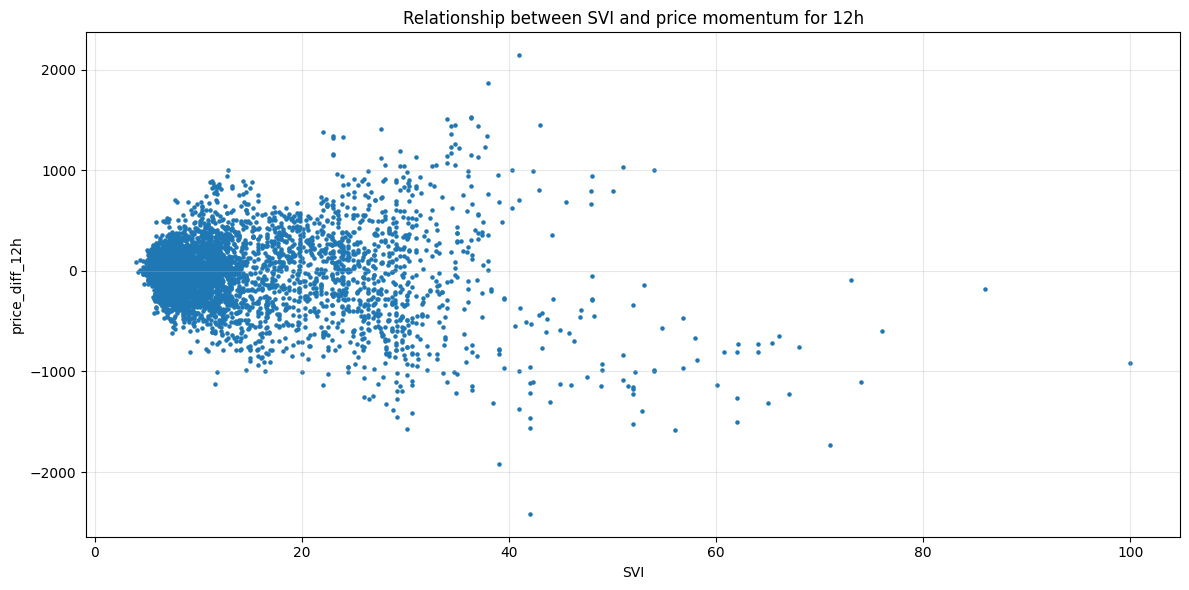

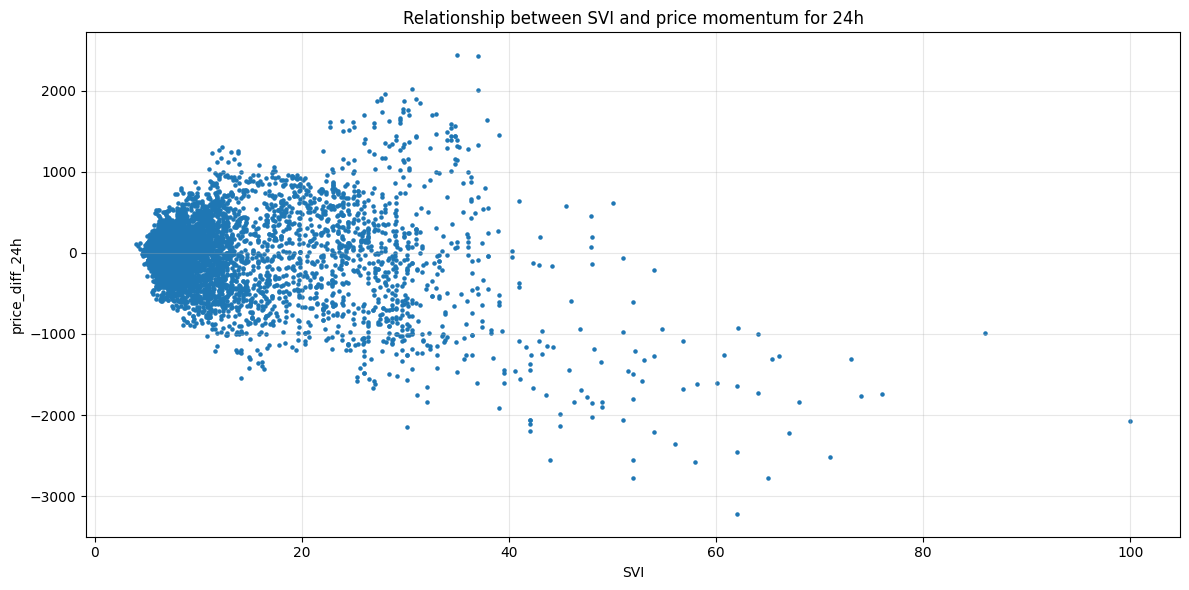

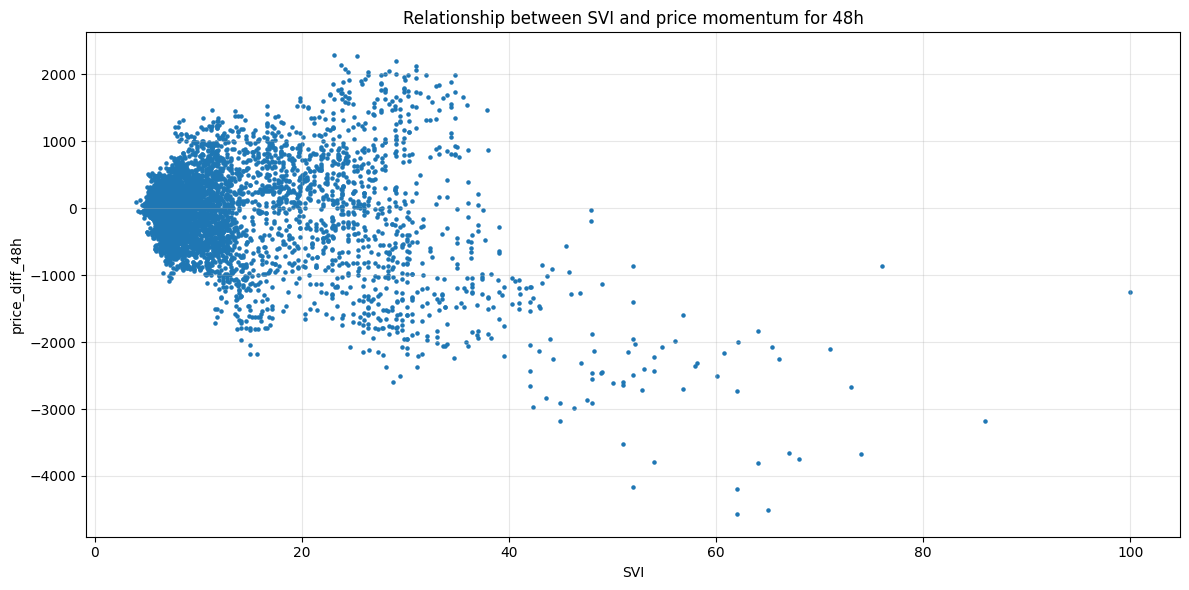

In [56]:
for h in hours:
    plot_scatter(df_svi_mom, "SVI", f"price_diff_{h}h", f"Relationship between SVI and price momentum for {h}h")


### Changes in SVI x momentum

In [57]:
for h in hours:
    corr_test(df_svi_mom, "d_SVI", f"price_diff_{h}h")


Correlation of d_SVI and price_diff_1h: 0.034
Correlation of d_SVI and price_diff_6h: 0.030
Correlation of d_SVI and price_diff_12h: 0.011
Correlation of d_SVI and price_diff_24h: 0.001
Correlation of d_SVI and price_diff_48h: 0.020


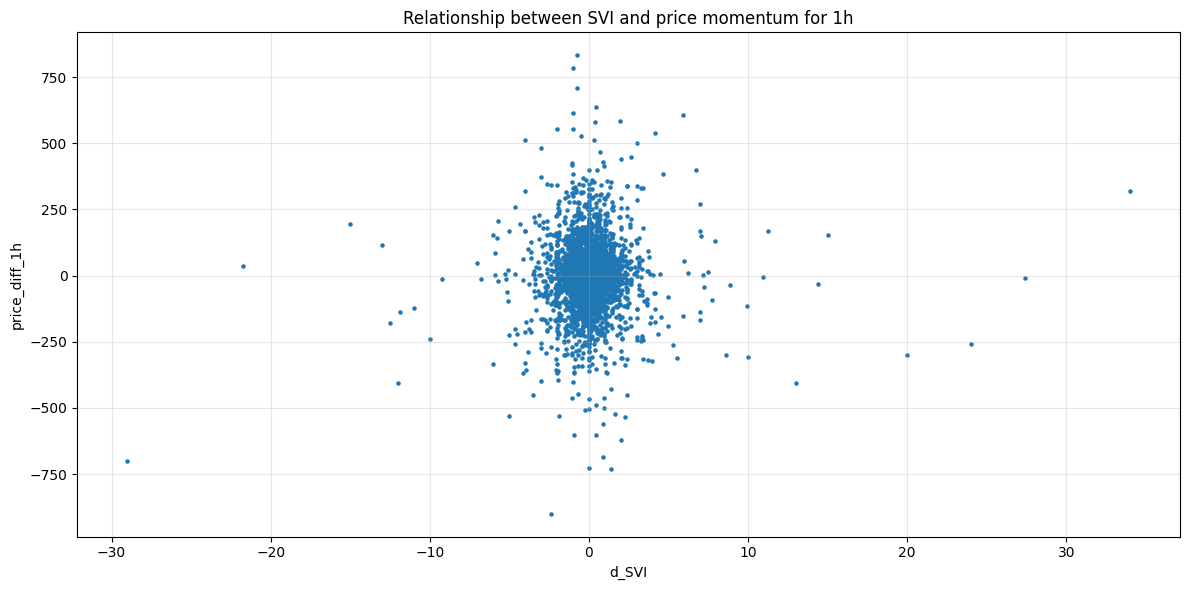

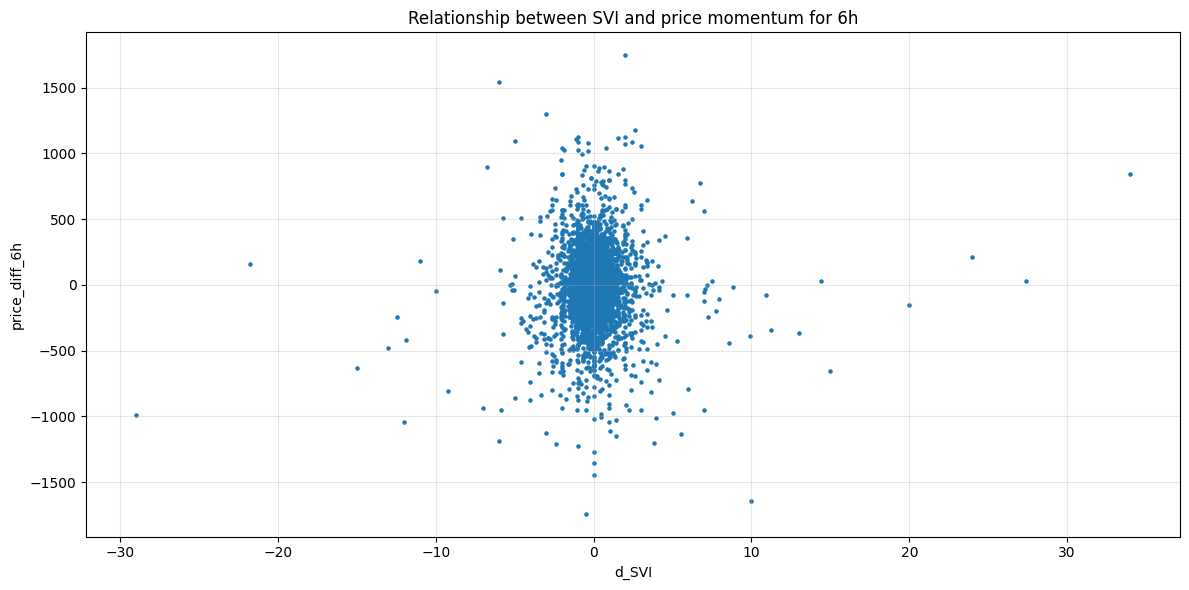

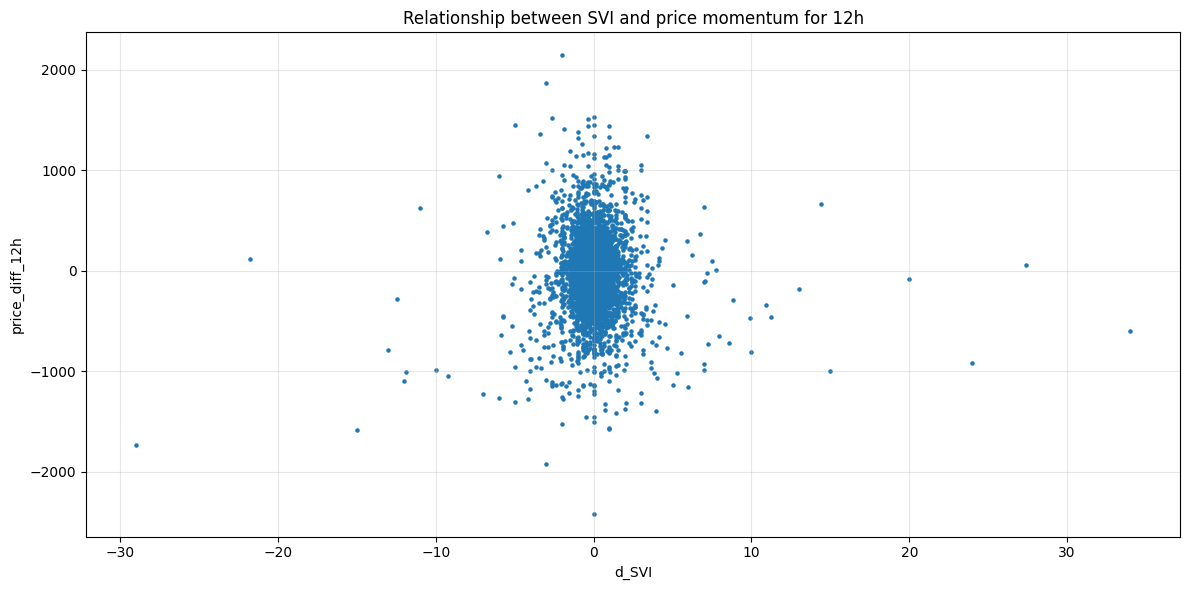

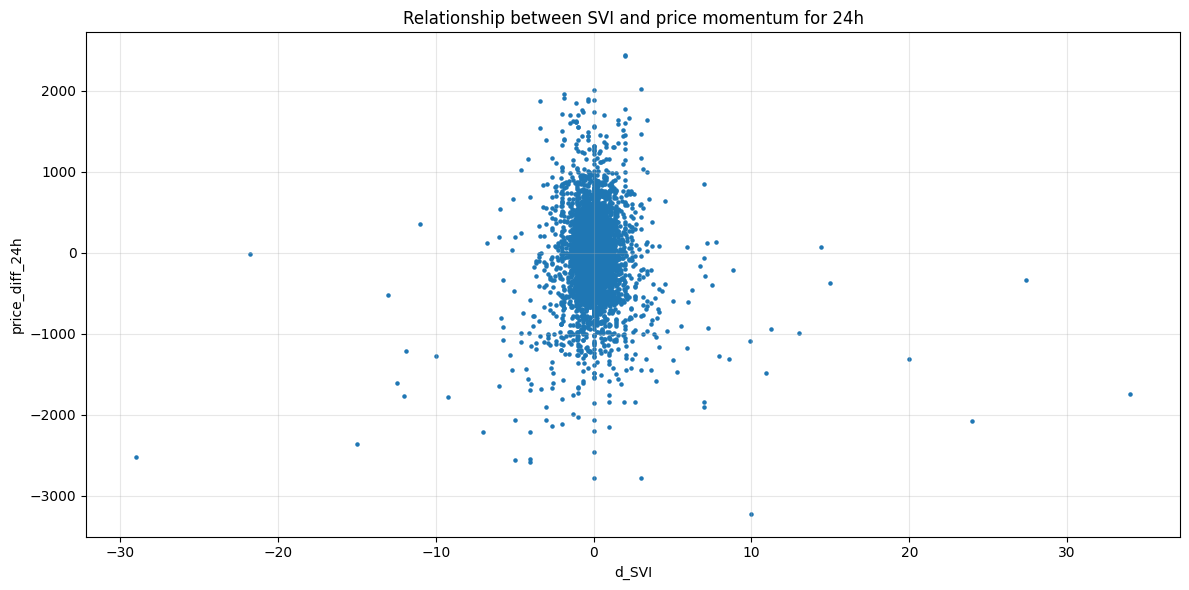

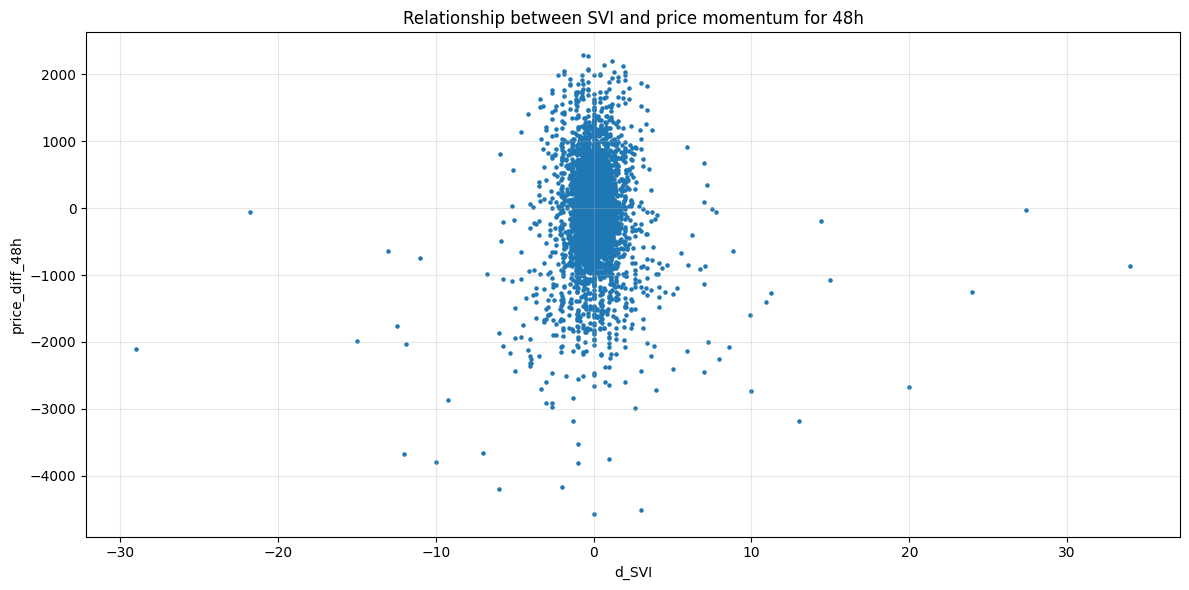

In [58]:
for h in hours:
    plot_scatter(df_svi_mom, "d_SVI", f"price_diff_{h}h", f"Relationship between SVI and price momentum for {h}h")
